# BBB Penetration Dataset Analysis and models for the Final Project of ACS Class

Miro Rava, Endrit Nazifi, Luca Lucchina, Matteo Del Grande



### 1) Distribution of the blood-brain barrier penetration labels in the dataset.

In [104]:
#imports
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from rdkit import Chem
from rdkit.Chem import Descriptors
from rdkit.Chem import MolStandardize
from rdkit.Chem import AllChem  
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from minisom import MiniSom
from sklearn.preprocessing import StandardScaler
from rdkit import RDLogger  
RDLogger.DisableLog('rdApp.*')   # Disable rdkit warnings

In [105]:
#check Nan
df_starter = pd.read_csv("BBB_Martins/full_data.csv")
nan_values = df_starter.isna()
print("Number of NaN values per column:")
print(nan_values.sum())

Number of NaN values per column:
Drug_ID    0
Drug       0
Y          0
dtype: int64


In [106]:
df_starter

,Drug_ID,Drug,Y
0,Propanolol,CC(C)NCC(O)COc1cccc2ccccc12.[Cl],1
1,Terbutylchlorambucil,CC(C)(C)OC(=O)CCCc1ccc(N(CCCl)CCCl)cc1,1
2,40730,CC1COc2c(N3CCN(C)CC3)c(F)cc3c(=O)c(C(=O)O)cn1c23,1
3,24,CC(=O)NCCCOc1cccc(CN2CCCCC2)c1,1
4,cloxacillin,Cc1onc(-c2ccccc2Cl)c1C(=O)N[C@@H]1C(=O)N2[C@@H...,1
...,...,...,...
2025,licostinel,O=c1[nH]c2cc(Cl)c(Cl)c([N+](=O)[O-])c2[nH]c1=O,1
2026,ademetionine(adenosyl-methionine),C[S+](CC[C@H](N)C(=O)[O-])C[C@H]1O[C@@H](n2cnc...,1
2027,mesocarb,CC(Cc1ccccc1)n1cc([N-]C(=O)Nc2ccccc2)[o+]n1,1
2028,tofisoline,CCc1c(C)[n+]([NH-])c(-c2ccc(OC)c(OC)c2)c2cc(OC...,1


In [107]:
def clean_and_deduplicate_smiles(df, smiles_col='Drug'):
    """
    Clean the database by removing missing values, converting SMILES to canonical form,
    and removing duplicates based on canonical SMILES.

    Parameters:
        df (pd.DataFrame): Input DataFrame containing a column with SMILES strings.
        smiles_col (str): Name of the column containing SMILES strings.

    Returns:
        pd.DataFrame: Cleaned DataFrame with duplicates removed.
    """
    # Drop missing values in the SMILES column
    df_clean = df.dropna(subset=[smiles_col]).copy()

    # Define a function to safely convert SMILES to canonical form
    def get_canonical_smiles(smiles):
        mol = Chem.MolFromSmiles(smiles)
        if mol is not None:
            return Chem.MolToSmiles(mol, canonical=True)
        else:
            return None

    # Convert SMILES to canonical form
    df_clean['Canonical_SMILES'] = df_clean[smiles_col].apply(get_canonical_smiles)
    # Remove rows with invalid SMILES and duplicates
    cleaned = df_clean.dropna(subset=['Canonical_SMILES']).drop_duplicates(subset='Canonical_SMILES').drop(columns='Canonical_SMILES')
    return cleaned

# Example usage:
# cleaned = clean_and_deduplicate_smiles(df_starter)

In [108]:
df=clean_and_deduplicate_smiles(df_starter)
df

,Drug_ID,Drug,Y
0,Propanolol,CC(C)NCC(O)COc1cccc2ccccc12.[Cl],1
1,Terbutylchlorambucil,CC(C)(C)OC(=O)CCCc1ccc(N(CCCl)CCCl)cc1,1
2,40730,CC1COc2c(N3CCN(C)CC3)c(F)cc3c(=O)c(C(=O)O)cn1c23,1
3,24,CC(=O)NCCCOc1cccc(CN2CCCCC2)c1,1
4,cloxacillin,Cc1onc(-c2ccccc2Cl)c1C(=O)N[C@@H]1C(=O)N2[C@@H...,1
...,...,...,...
2025,licostinel,O=c1[nH]c2cc(Cl)c(Cl)c([N+](=O)[O-])c2[nH]c1=O,1
2026,ademetionine(adenosyl-methionine),C[S+](CC[C@H](N)C(=O)[O-])C[C@H]1O[C@@H](n2cnc...,1
2027,mesocarb,CC(Cc1ccccc1)n1cc([N-]C(=O)Nc2ccccc2)[o+]n1,1
2028,tofisoline,CCc1c(C)[n+]([NH-])c(-c2ccc(OC)c(OC)c2)c2cc(OC...,1


In [109]:
nan_values = df.isna()
print("Number of NaN values per column:")
print(nan_values.sum())

Number of NaN values per column:
Drug_ID    0
Drug       0
Y          0
dtype: int64


In [110]:
import plotly.express as px
import plotly.graph_objects as go
#with cleaned dataset, extracting feature needed and plotting distribution
p_np_labels = df['Y'] # extract the p_pn column

# Count the occurrences of each label
value_counts = p_np_labels.value_counts().reset_index()
value_counts.columns = ['Y', 'Count']
value_counts['Percentage'] = (value_counts['Count'] / value_counts['Count'].sum() * 100).round(2)

# Create labels for the plot
value_counts['Label_text'] = value_counts['Y'].map({0: 'Non-penetrating', 1: 'Penetrating'})

# Create an interactive bar chart with Plotly
fig = px.bar(
    value_counts, 
    x='Label_text', 
    y='Count',
    text=[f"{c} ({p}%)" for c, p in zip(value_counts['Count'], value_counts['Percentage'])],
    color='Label_text',
    color_discrete_map={
        'Non-penetrating': '#FF6B6B', 
        'Penetrating': '#4ECDC4'
    },
    title='Distribution of Blood-Brain Barrier Penetration Labels'
)

# Customize the layout
fig.update_layout(
    xaxis_title='BBB Penetration Label',
    yaxis_title='Frequency',
    showlegend=False,
    hoverlabel=dict(bgcolor="white", font_size=12),
    plot_bgcolor='rgba(240,240,240,0.8)'
)

# Show the plot
fig.show()

# Print distribution statistics for discussion
print(f"Penetrating molecules: {value_counts.loc[value_counts['Y']==1, 'Count'].iloc[0]} ({value_counts.loc[value_counts['Y']==1, 'Percentage'].iloc[0]}%)")
print(f"Non-penetrating molecules: {value_counts.loc[value_counts['Y']==0, 'Count'].iloc[0] if len(value_counts[value_counts['Y']==0]) > 0 else 0} "
      f"({value_counts.loc[value_counts['Y']==0, 'Percentage'].iloc[0] if len(value_counts[value_counts['Y']==0]) > 0 else 0}%)")

Penetrating molecules: 1501 (76.0%)
Non-penetrating molecules: 474 (24.0%)


 Looking at the distribution visualization, we observe a significant class imbalance:
 - Penetrating molecules (76.0%): 1501 instances
 - Non-penetrating molecules (24.0%): 474 instances

 This imbalance has several implications for classification tasks:
 1. Model Bias: Classification algorithms may become biased toward the majority class 
    (penetrating molecules), potentially leading to poor performance in identifying 
    non-penetrating molecules.
 2. Evaluation Metrics: Accuracy would be a misleading metric in this case, as a model 
    always predicting "penetrating" would achieve 76% accuracy without learning any 
    meaningful patterns.
 3. Practical Implications: In drug development, failing to identify non-penetrating 
    molecules (false positives) could lead to wasted resources on compounds that 
    cannot reach the brain.

 Strategies to address this imbalance could include:
 - Resampling techniques: Oversampling the minority class or undersampling the majority class
 - Using weighted loss functions that penalize misclassifications of the minority class more heavily
 - Employing ensemble methods specifically designed for imbalanced data
 - Using evaluation metrics better suited for imbalanced datasets (F1-score, precision-recall AUC, 
   balanced accuracy)

---

### 2)PCA and t-SNE.


In [111]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from rdkit.Chem import rdFingerprintGenerator
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Generate Morgan fingerprint generator with radius 2 and 2048 bits
mfpgen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)

# Convert SMILES to RDKit molecule objects
mols = [Chem.MolFromSmiles(smiles) for smiles in df['Drug']]
mols = [mol for mol in mols if mol is not None]  # Filter out None values

# Extract penetration labels for valid molecules
valid_indices = [i for i, mol in enumerate(mols) if mol is not None]
labels = df['Y'].iloc[valid_indices].values

# Generate Morgan fingerprints (ECFP) with 2048 bits
print("Generating molecular fingerprints...")
fingerprints = [mfpgen.GetFingerprint(mol) for mol in mols]
fingerprints_array = np.array([list(fp) for fp in fingerprints])

# Apply PCA for dimensionality reduction (Calculate 3 components)
print("Applying PCA...")
pca = PCA(n_components=3) # Changed to 3 components
pca_result = pca.fit_transform(fingerprints_array)
explained_variance_3pcs = pca.explained_variance_ratio_.sum()
print(f"Explained variance ratio with first 3 PCA components: {explained_variance_3pcs:.3f}")
print(f"Individual component variance: PC1={pca.explained_variance_ratio_[0]:.3f}, PC2={pca.explained_variance_ratio_[1]:.3f}, PC3={pca.explained_variance_ratio_[2]:.3f}")


# Apply t-SNE for dimensionality reduction
print("Applying t-SNE...")
tsne = TSNE(n_components=3, random_state=42, perplexity=30, n_iter=1000)
tsne_result = tsne.fit_transform(fingerprints_array)

# Create a dataframe with all the results for easier plotting
viz_df = pd.DataFrame({
    'PCA_1': pca_result[:, 0],
    'PCA_2': pca_result[:, 1],
    'PCA_3': pca_result[:, 2],
    'tSNE_1': tsne_result[:, 0],
    'tSNE_2': tsne_result[:, 1],
    'tSNE_3': tsne_result[:, 2],
    'Penetration': labels,
    'PenetrationLabel': ['Penetrating' if l == 1 else 'Non-penetrating' for l in labels],
    'Drug_ID': df['Drug_ID'].iloc[valid_indices].values,
    'Drug': df['Drug'].iloc[valid_indices].values
})

fig_pca_3d = go.Figure(data=[go.Scatter3d(
    x=viz_df['PCA_1'],
    y=viz_df['PCA_2'],
    z=viz_df['PCA_3'],
    mode='markers',
    marker=dict(
        size=6, # Slightly smaller markers for 3D
        color=viz_df['Penetration'], # Color by penetration label
        colorscale='RdBu_r',        # Color scale
        opacity=0.7,
        colorbar=dict(
            title='BBB Penetration',
            tickvals=[0, 1],
            ticktext=['Non-penetrating', 'Penetrating']
        )
    ),
    text=viz_df['Drug_ID'], # Show Drug_ID on hover
    hoverinfo='text'
)])

# Update layout for PCA 3D plot
fig_pca_3d.update_layout(
    title=f'PCA 3D Visualization of Chemical Space (Explained Var: {explained_variance_3pcs:.3f})',
    scene=dict(
        xaxis_title=f'Principal Component 1 ({pca.explained_variance_ratio_[0]:.3f})',
        yaxis_title=f'Principal Component 2 ({pca.explained_variance_ratio_[1]:.3f})',
        zaxis_title=f'Principal Component 3 ({pca.explained_variance_ratio_[2]:.3f})'
    ),
    width=800,
    height=700,
    margin=dict(l=0, r=0, b=0, t=40),
    template="plotly_white"
)
fig_pca_3d.show()


# --- t-SNE 2D Visualization ---
fig_tsne = go.Figure(data=[go.Scatter3d(
    x=viz_df['tSNE_1'],
    y=viz_df['tSNE_2'],
    z=viz_df['tSNE_3'],
    mode='markers',
    marker=dict(
        size=6,
        color=viz_df['Penetration'],
        colorscale='RdBu_r',
        opacity=0.7,
        line=dict(width=0.5, color='DarkSlateGrey'),
        colorbar=dict(
            title='BBB Penetration',
            tickvals=[0, 1],
            ticktext=['Non-penetrating', 'Penetrating']
        )
    ),
    text=viz_df['Drug_ID'],
    hoverinfo='text',
    hovertemplate='<b>Name:</b> %{text}<br><b>Penetration:</b> %{marker.color}<extra></extra>'
)])

# Update layout for t-SNE plot
fig_tsne.update_layout(
    title='t-SNE Visualization of Chemical Space',
    scene=dict(
        xaxis_title=f't-SNE Component 1',
        yaxis_title=f't-SNE Component 2',
        zaxis_title=f't-SNE Component 3'
    ),
    width=800,
    height=700,
    template="plotly_white",
    hoverlabel=dict(bgcolor="white", font_size=12),
    margin=dict(l=0, r=0, t=0, b=0)
)
fig_tsne.show()

# Add detailed analysis
print("\nAnalysis of Chemical Space Visualization:")
print("------------------------------------------")
print(f"PCA visualization explains {pca.explained_variance_ratio_.sum():.2f} of the total variance, preserving global structure.")
print("t-SNE visualization preserves local neighborhoods and can reveal more detailed clusters.")
print(f"Number of penetrating molecules (1): {sum(labels == 1)} ({sum(labels == 1)/len(labels)*100:.1f}%)")
print(f"Number of non-penetrating molecules (0): {sum(labels == 0)} ({sum(labels == 0)/len(labels)*100:.1f}%)")

# Class distribution in visualized space
print("\nClass Distribution Analysis:")
pca_penetrating = viz_df[viz_df['Penetration'] == 1][['PCA_1', 'PCA_2', "PCA_3"]]
pca_nonpenetrating = viz_df[viz_df['Penetration'] == 0][['PCA_1', 'PCA_2', "PCA_3"]]
tsne_penetrating = viz_df[viz_df['Penetration'] == 1][['tSNE_1', 'tSNE_2', "tSNE_3"]]
tsne_nonpenetrating = viz_df[viz_df['Penetration'] == 0][['tSNE_1', 'tSNE_2', "tSNE_3"]]

print(f"PCA - Mean position for penetrating molecules: ({pca_penetrating['PCA_1'].mean():.3f}, {pca_penetrating['PCA_2'].mean():.3f}, {pca_penetrating['PCA_3'].mean():.3f} )")
print(f"PCA - Mean position for non-penetrating molecules: ({pca_nonpenetrating['PCA_1'].mean():.3f}, {pca_nonpenetrating['PCA_2'].mean():.3f}, {pca_nonpenetrating['PCA_3'].mean():.3f})")
print(f"t-SNE - Mean position for penetrating molecules: ({tsne_penetrating['tSNE_1'].mean():.3f}, {tsne_penetrating['tSNE_2'].mean():.3f}, {tsne_penetrating['tSNE_3'].mean():.3f})")
print(f"t-SNE - Mean position for non-penetrating molecules: ({tsne_nonpenetrating['tSNE_1'].mean():.3f}, {tsne_nonpenetrating['tSNE_2'].mean():.3f}, {tsne_penetrating['tSNE_3'].mean():.3f})")

Generating molecular fingerprints...
Applying PCA...
Explained variance ratio with first 3 PCA components: 0.109
Individual component variance: PC1=0.051, PC2=0.030, PC3=0.027
Applying t-SNE...


c:\Users\miror\Dropbox\SUPSI\Terzo Anno_Secondo Semestre\ACS_Grasso\ACS_GRASSO_venv\lib\site-packages\sklearn\manifold\_t_sne.py:1164: FutureWarning:

'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.




Analysis of Chemical Space Visualization:
------------------------------------------
PCA visualization explains 0.11 of the total variance, preserving global structure.
t-SNE visualization preserves local neighborhoods and can reveal more detailed clusters.
Number of penetrating molecules (1): 1501 (76.0%)
Number of non-penetrating molecules (0): 474 (24.0%)

Class Distribution Analysis:
PCA - Mean position for penetrating molecules: (-0.102, -0.270, -0.084 )
PCA - Mean position for non-penetrating molecules: (0.325, 0.857, 0.266)
t-SNE - Mean position for penetrating molecules: (2.151, -1.196, -3.857)
t-SNE - Mean position for non-penetrating molecules: (-7.233, 4.310, -3.857)


### Analysis

#### PCA Visualization:
- **Explained Variance**: The PCA visualization explains 11% of the total variance in the dataset. This indicates that while PCA captures some of the global structure of the data, it does not account for most of the variance. This is typical in high-dimensional chemical datasets where a few principal components cannot capture all the complexity.
- **Class Distribution**: 
    - The mean positions suggest that penetrating and non-penetrating molecules are somewhat separated in the PCA space, but there is still significant overlap. This overlap indicates that PCA alone may not be sufficient to distinguish between the two classes effectively.

#### t-SNE Visualization:
- **Local Neighborhoods**: t-SNE is effective in preserving local neighborhoods, which means it can reveal more detailed clusters and relationships between molecules that are similar in their high-dimensional space.
- **Class Distribution**:
    - The t-SNE visualization shows a more distinct separation between penetrating and non-penetrating molecules in local clusters compared to PCA. This suggests that t-SNE is better at capturing the local structure and differences between the two classes.

#### Justification:
- **PCA**: While PCA is useful for reducing dimensionality and capturing global structure, it may not be the best choice for datasets with complex, non-linear relationships like chemical datasets. The explained variance of 11% indicates that much of the data's complexity is not captured by the first two principal components.
- **t-SNE**: t-SNE excels in visualizing high-dimensional data by preserving local neighborhoods, making it more suitable for identifying clusters and patterns that are not apparent in PCA. The distinct local cluster separation in t-SNE plots suggests that it can better differentiate between penetrating and non-penetrating molecules that are grouped togheter.

---

### 3) Distribution of interpretable physicochemical properties


In [112]:
from rdkit.Chem import Descriptors, Lipinski, MolSurf

# Calculate and analyze physicochemical properties

# Function to calculate molecular properties
def calculate_properties(mol):
    if mol is None:
        return None
    
    properties = {
        'MW': Descriptors.MolWt(mol),
        'LogP': Descriptors.MolLogP(mol),
        'HBD': Descriptors.NumHDonors(mol),
        'HBA': Descriptors.NumHAcceptors(mol),
        'TPSA': MolSurf.TPSA(mol),
        'Rotatable_Bonds': Descriptors.NumRotatableBonds(mol),
        'Aromatic_Rings': Descriptors.NumAromaticRings(mol),
        'Heavy_Atoms': mol.GetNumHeavyAtoms(),
        'Fraction_CSP3': Descriptors.FractionCSP3(mol),  # Fraction of SP3 carbons
        'QED': Descriptors.qed(mol)  # Drug-likeness score
    }
    return properties

# Calculate properties for all molecules
print("Calculating molecular properties...")
properties_list = []
for i, mol in enumerate(mols):
    props = calculate_properties(mol)
    if props is not None:
        props['Y'] = df['Y'].iloc[valid_indices[i]]
        properties_list.append(props)

# Create dataframe with properties
prop_df = pd.DataFrame(properties_list)

# Add class labels for easier plotting
prop_df['Class'] = prop_df['Y'].map({1: 'Penetrating', 0: 'Non-penetrating'})

# Create subplots with 3x3 grid for main properties
fig = make_subplots(rows=3, cols=3, 
                   subplot_titles=('Molecular Weight', 'LogP', 'Hydrogen Bond Donors', 
                                  'Hydrogen Bond Acceptors', 'Topological PSA', 'Rotatable Bonds',
                                  'Aromatic Rings', 'Heavy Atoms', 'Fraction CSP3'))

# Define properties to plot and their positions
properties = [
    {'Drug_ID': 'MW', 'row': 1, 'col': 1, 'title': 'Molecular Weight (Da)'},
    {'Drug_ID': 'LogP', 'row': 1, 'col': 2, 'title': 'LogP (Lipophilicity)'},
    {'Drug_ID': 'HBD', 'row': 1, 'col': 3, 'title': 'Hydrogen Bond Donors'},
    {'Drug_ID': 'HBA', 'row': 2, 'col': 1, 'title': 'Hydrogen Bond Acceptors'},
    {'Drug_ID': 'TPSA', 'row': 2, 'col': 2, 'title': 'Topological PSA (Å²)'},
    {'Drug_ID': 'Rotatable_Bonds', 'row': 2, 'col': 3, 'title': 'Rotatable Bonds'},
    {'Drug_ID': 'Aromatic_Rings', 'row': 3, 'col': 1, 'title': 'Aromatic Rings'},
    {'Drug_ID': 'Heavy_Atoms', 'row': 3, 'col': 2, 'title': 'Heavy Atoms'},
    {'Drug_ID': 'Fraction_CSP3', 'row': 3, 'col': 3, 'title': 'Fraction CSP3'}
]

# Colors for the two classes
colors = {'Penetrating': '#4ECDC4', 'Non-penetrating': '#FF6B6B'}

# Add density plots for each property
for prop in properties:
    for cls in ['Penetrating', 'Non-penetrating']:
        data = prop_df[prop_df['Class'] == cls][prop['Drug_ID']]
        
        fig.add_trace(
            go.Violin(
                x=data,
                name=cls,
                line_color=colors[cls],
                side='positive',
                meanline_visible=True,
                showlegend=True if (prop['row'] == 1 and prop['col'] == 1) else False,
                legendgroup=cls,
                scalemode='width',
                width=2,
                points=False
            ),
            row=prop['row'], col=prop['col']
        )

# Update layout for larger plots and better appearance
fig.update_layout(
    height=1200,  # Increased height
    width=1500,   # Increased width
    title_text="Distribution of Physicochemical Properties for BBB Penetrating vs. Non-penetrating Molecules",
    title_font_size=20,
    legend_title="BBB Penetration",
    template="plotly_white",
    violinmode='overlay'  # This ensures violins are overlaid rather than side by side
)

# Add annotations explaining the significance of each property, now positioned below each subplot
annotations = [
    dict(x=0.16, y=0.65, text="Low MW (<400) favors BBB penetration", showarrow=False, xref="paper", yref="paper"),
    dict(x=0.5, y=0.65, text="Optimal LogP (1-4) improves penetration", showarrow=False, xref="paper", yref="paper"),
    dict(x=0.85, y=0.65, text="Fewer H-bond donors enhance BBB crossing", showarrow=False, xref="paper", yref="paper"),
    dict(x=0.16, y=0.30, text="Fewer acceptors improve penetration", showarrow=False, xref="paper", yref="paper"),
    dict(x=0.5, y=0.30, text="Lower TPSA (<70 Å²) favors penetration", showarrow=False, xref="paper", yref="paper"),
    dict(x=0.85, y=0.30, text="Fewer rotatable bonds enhance BBB passage", showarrow=False, xref="paper", yref="paper"),
    dict(x=0.16, y=-0.07, text="Aromatic rings can affect penetration", showarrow=False, xref="paper", yref="paper"),
    dict(x=0.5, y=-0.07, text="Smaller molecules cross BBB more easily", showarrow=False, xref="paper", yref="paper"),
    dict(x=0.85, y=-0.07, text="Higher sp3 fraction can improve properties", showarrow=False, xref="paper", yref="paper")
]

fig.update_layout(annotations=annotations)

# Update axes for better appearance
fig.update_xaxes(showgrid=True, gridwidth=1, gridcolor='LightGray')
fig.update_yaxes(showgrid=True, gridwidth=1, gridcolor='LightGray')

for prop in properties:
    fig.update_yaxes(title_text="Density", row=prop['row'], col=prop['col'])
    fig.update_xaxes(title_text=prop['title'], row=prop['row'], col=prop['col'])

# Add a QED plot separately
fig_qed = px.violin(prop_df, x="QED", color="Class", 
                    box=True, points=False,
                    color_discrete_map=colors,
                    labels={"QED": "Quantitative Estimation of Drug-likeness"},
                    title="Distribution of Drug-likeness (QED) Score")

fig_qed.update_layout(template="plotly_white", legend_title="BBB Penetration", violinmode='overlay')

# Show the plots
fig.show()
fig_qed.show()

# Statistical analysis to determine whether properties can distinguish between classes
print("\nStatistical Summary of Properties by Class:")
penetrating = prop_df[prop_df['Class'] == 'Penetrating']
non_penetrating = prop_df[prop_df['Class'] == 'Non-penetrating']

summary_stats = pd.DataFrame({
    'Property': [p['Drug_ID'] for p in properties] + ['QED'],
    'Penetrating_Mean': [penetrating[p['Drug_ID']].mean() for p in properties] + [penetrating['QED'].mean()],
    'Non_Penetrating_Mean': [non_penetrating[p['Drug_ID']].mean() for p in properties] + [non_penetrating['QED'].mean()],
    'Difference': [penetrating[p['Drug_ID']].mean() - non_penetrating[p['Drug_ID']].mean() for p in properties] + 
                  [penetrating['QED'].mean() - non_penetrating['QED'].mean()],
    'Percent_Difference': [100 * (penetrating[p['Drug_ID']].mean() - non_penetrating[p['Drug_ID']].mean()) / 
                          non_penetrating[p['Drug_ID']].mean() for p in properties] + 
                          [100 * (penetrating['QED'].mean() - non_penetrating['QED'].mean()) / 
                           non_penetrating['QED'].mean()]
})

print(summary_stats.sort_values(by='Percent_Difference', ascending=False).round(3))

Calculating molecular properties...



Statistical Summary of Properties by Class:
          Property  Penetrating_Mean  Non_Penetrating_Mean  Difference  \
1             LogP             2.668                 1.149       1.519   
9              QED             0.674                 0.458       0.216   
6   Aromatic_Rings             1.404                 1.414      -0.009   
8    Fraction_CSP3             0.461                 0.472      -0.011   
7      Heavy_Atoms            22.262                30.338      -8.076   
0               MW           317.604               439.011    -121.406   
5  Rotatable_Bonds             3.810                 5.458      -1.648   
3              HBA             3.754                 7.367      -3.613   
4             TPSA            54.120               127.156     -73.035   
2              HBD             1.058                 3.177      -2.119   

   Percent_Difference  
1             132.170  
9              47.117  
6              -0.644  
8              -2.256  
7             -26.62

### **Descriptor Analysis & Interpretation:**

1. **Molecular Weight (MW)**
   - **Observation**: BBB-penetrating molecules have a lower average MW (~318 Da) compared to non-penetrating ones (~440 Da).
   - **Interpretation**: Lower molecular weight favors permeability, as smaller molecules diffuse more easily through the blood-brain barrier (BBB). Larger molecules tend to have poor penetration.

2. **LogP (Lipophilicity)**
   - **Observation**: LogP is significantly higher in penetrating molecules (~2.67) than in non-penetrating ones (~1.15).
   - **Interpretation**: Lipophilicity plays a crucial role in BBB permeability. A moderate LogP (typically between 1-4) enhances penetration by promoting passive diffusion across lipid membranes.

3. **Hydrogen Bond Donors (HBD)**
   - **Observation**: BBB-penetrating molecules have significantly fewer HBDs (~1.06) compared to non-penetrating ones (~3.18).
   - **Interpretation**: Fewer hydrogen bond donors reduce interactions with aqueous environments, improving lipophilic character and passive diffusion.

4. **Hydrogen Bond Acceptors (HBA)**
   - **Observation**: Penetrating molecules have fewer HBAs (~3.75) than non-penetrating ones (~7.37).
   - **Interpretation**: Similar to HBD, fewer HBAs reduce water affinity, increasing lipophilicity and improving BBB penetration.

5. **Topological Polar Surface Area (TPSA)**
   - **Observation**: TPSA is lower in BBB-penetrating molecules (~54 Å²) compared to non-penetrating (~127 Å²).
   - **Interpretation**: A lower TPSA (<70 Å²) is favorable for BBB penetration as it reduces hydrophilicity and improves lipid solubility.

6. **Rotatable Bonds**
   - **Observation**: Penetrating molecules have fewer rotatable bonds (~3.81) compared to non-penetrating (~5.46).
   - **Interpretation**: Reduced molecular flexibility enhances passive diffusion by maintaining a compact conformation suitable for membrane permeability.

7. **Heavy Atoms**
   - **Observation**: Penetrating molecules contain fewer heavy atoms (~22.26) than non-penetrating molecules (~30.34).
   - **Interpretation**: Smaller molecular structures, with fewer heavy atoms, correlate with higher BBB penetration.

8. **Aromatic Rings**
   - **Observation**: No significant difference (~1.40 in permeable vs. ~1.41 in non-permeable).
   - **Interpretation**: The number of aromatic rings alone does not significantly impact permeability.

9. **Fraction of sp3 Carbon (Fraction_CSP3)**
   - **Observation**: No strong difference (~0.461 vs. ~0.472).
   - **Interpretation**: While sp3 hybridization affects 3D conformation, it does not seem to distinguish permeability significantly.

10. **QED (Quantitative Estimate of Drug-likeness)**
    - **Observation**: Higher QED in penetrating molecules (~0.67) than in non-penetrating (~0.46).
    - **Interpretation**: Higher QED suggests that BBB-penetrating molecules tend to have more drug-like properties, balancing lipophilicity and molecular weight.

### **Key Insights & Conclusions:**
- **Distinguishing Properties**:
  - **Most Distinguishing**: LogP, MW, HBD, HBA, TPSA.
  - **Less Significant**: Aromatic rings, Fraction_CSP3.
- **Ideal BBB-Penetration Profile**:
  - **MW**: <400 Da
  - **LogP**: Between 1-4
  - **TPSA**: <70 Å²
  - **HBD & HBA**: Low count (<2 HBD, <5 HBA)
  - **Rotatable Bonds**: Fewer for rigidity

I've taken many of the considerations written above from internet and various scientific sources, since i'm not an expert in BBB-penetrating molecules

In [113]:
prop_df.drop(columns=['Y', 'Class'], inplace=True)
prop_df

,MW,LogP,HBD,HBA,TPSA,Rotatable_Bonds,Aromatic_Rings,Heavy_Atoms,Fraction_CSP3,QED
0,294.802,3.26700,2,3,41.49,6,2,20,0.375000,0.859050
1,360.325,4.63500,0,3,29.54,9,1,23,0.611111,0.474821
2,361.373,1.54400,1,6,75.01,2,2,26,0.444444,0.874740
3,290.407,2.57750,1,3,41.57,7,1,21,0.588235,0.784810
4,435.889,2.54872,2,6,112.74,4,2,29,0.368421,0.709265
...,...,...,...,...,...,...,...,...,...,...
1970,276.035,1.43140,2,4,108.86,1,2,17,0.000000,0.466075
1971,398.445,-3.25690,4,11,185.46,7,2,27,0.600000,0.344970
1972,322.368,4.79820,1,3,72.32,5,3,24,0.166667,0.685827
1973,382.460,4.51482,0,4,64.60,6,3,28,0.318182,0.588327


In [114]:
#combine df and prop_df on index
df = df.reset_index(drop=True)
prop_df = prop_df.reset_index(drop=True)
df = pd.concat([df, prop_df], axis=1)
df

,Drug_ID,Drug,Y,MW,LogP,HBD,HBA,TPSA,Rotatable_Bonds,Aromatic_Rings,Heavy_Atoms,Fraction_CSP3,QED
0,Propanolol,CC(C)NCC(O)COc1cccc2ccccc12.[Cl],1,294.802,3.26700,2,3,41.49,6,2,20,0.375000,0.859050
1,Terbutylchlorambucil,CC(C)(C)OC(=O)CCCc1ccc(N(CCCl)CCCl)cc1,1,360.325,4.63500,0,3,29.54,9,1,23,0.611111,0.474821
2,40730,CC1COc2c(N3CCN(C)CC3)c(F)cc3c(=O)c(C(=O)O)cn1c23,1,361.373,1.54400,1,6,75.01,2,2,26,0.444444,0.874740
3,24,CC(=O)NCCCOc1cccc(CN2CCCCC2)c1,1,290.407,2.57750,1,3,41.57,7,1,21,0.588235,0.784810
4,cloxacillin,Cc1onc(-c2ccccc2Cl)c1C(=O)N[C@@H]1C(=O)N2[C@@H...,1,435.889,2.54872,2,6,112.74,4,2,29,0.368421,0.709265
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1970,licostinel,O=c1[nH]c2cc(Cl)c(Cl)c([N+](=O)[O-])c2[nH]c1=O,1,276.035,1.43140,2,4,108.86,1,2,17,0.000000,0.466075
1971,ademetionine(adenosyl-methionine),C[S+](CC[C@H](N)C(=O)[O-])C[C@H]1O[C@@H](n2cnc...,1,398.445,-3.25690,4,11,185.46,7,2,27,0.600000,0.344970
1972,mesocarb,CC(Cc1ccccc1)n1cc([N-]C(=O)Nc2ccccc2)[o+]n1,1,322.368,4.79820,1,3,72.32,5,3,24,0.166667,0.685827
1973,tofisoline,CCc1c(C)[n+]([NH-])c(-c2ccc(OC)c(OC)c2)c2cc(OC...,1,382.460,4.51482,0,4,64.60,6,3,28,0.318182,0.588327


---

### 4) Best algorithm and chemical fingerprint selection to clusterize molecules in the dataset.

In [115]:
from rdkit.Chem import rdMolDescriptors, AllChem, rdFingerprintGenerator
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.metrics import adjusted_rand_score as adjusted_rand_index
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd
import seaborn as sns
from collections import Counter
from plotly.subplots import make_subplots
from rdkit import DataStructs  # For Tanimoto similarity calculation
import matplotlib.pyplot as plt
import plotly.graph_objects as go
# Add import for Self-Organizing Maps
from minisom import MiniSom

mfpgen = rdFingerprintGenerator.GetMorganGenerator(radius=2,fpSize=2048)
rdkgen = rdFingerprintGenerator.GetRDKitFPGenerator(fpSize=2048)
apgen = rdFingerprintGenerator.GetAtomPairGenerator(fpSize=2048)
ttgen = rdFingerprintGenerator.GetTopologicalTorsionGenerator(fpSize=2048)

# Generate different types of fingerprints
print("Generating different types of molecular fingerprints...")
fingerprint_types = {
    'Morgan (ECFP4)': [],
    'MACCS Keys': [],
    'AtomPair': [],
    'Topological Torsion': [],
    'RDKit': []
}

# Store original fingerprint objects for Tanimoto calculation
original_fingerprints = {
    'Morgan (ECFP4)': [],
    'MACCS Keys': [],
    'AtomPair': [],
    'Topological Torsion': [],
    'RDKit': []
}

for mol in mols:
    if mol is not None:
        # Morgan/ECFP4 fingerprint (radius 2 corresponds to ECFP4)
        morgan_fp = mfpgen.GetFingerprint(mol)
        fingerprint_types['Morgan (ECFP4)'].append(np.array(morgan_fp))
        original_fingerprints['Morgan (ECFP4)'].append(morgan_fp)
        
        # MACCS Keys (166 bits)
        maccs_fp = rdMolDescriptors.GetMACCSKeysFingerprint(mol)
        fingerprint_types['MACCS Keys'].append(np.array(maccs_fp))
        original_fingerprints['MACCS Keys'].append(maccs_fp)
        
        # Atom Pair fingerprint
        ap_fp = apgen.GetFingerprint(mol)
        fingerprint_types['AtomPair'].append(np.array(ap_fp))
        original_fingerprints['AtomPair'].append(ap_fp)
        
        # Topological Torsion fingerprint
        tt_fp = ttgen.GetFingerprint(mol)
        fingerprint_types['Topological Torsion'].append(np.array(tt_fp))
        original_fingerprints['Topological Torsion'].append(tt_fp)
        
        # RDKit fingerprint
        rdkit_fp = rdkgen.GetFingerprint(mol)
        fingerprint_types['RDKit'].append(np.array(rdkit_fp))
        original_fingerprints['RDKit'].append(rdkit_fp)

# Convert lists to numpy arrays
for fp_type in fingerprint_types:
    fingerprint_types[fp_type] = np.array(fingerprint_types[fp_type])

# Calculate Tanimoto similarity matrices for each fingerprint type
print("\nCalculating Tanimoto similarity matrices...")
tanimoto_matrices = {}
tanimoto_stats = {}

for fp_name, fp_list in original_fingerprints.items():
    n = len(fp_list)
    tanimoto_matrix = np.zeros((n, n))
    
    # Calculate all pairwise Tanimoto similarities
    for i in range(n):
        for j in range(i, n):
            sim = DataStructs.TanimotoSimilarity(fp_list[i], fp_list[j])
            tanimoto_matrix[i, j] = sim
            tanimoto_matrix[j, i] = sim
    
    tanimoto_matrices[fp_name] = tanimoto_matrix
    
    # Calculate similarity statistics between penetrating and non-penetrating compounds
    penetrating_indices = [i for i, label in enumerate(labels) if label == 1]
    nonpenetrating_indices = [i for i, label in enumerate(labels) if label == 0]
    
    # Within-class similarities
    pen_pen_sims = [tanimoto_matrix[i, j] for i in penetrating_indices for j in penetrating_indices if i < j]
    nonpen_nonpen_sims = [tanimoto_matrix[i, j] for i in nonpenetrating_indices for j in nonpenetrating_indices if i < j]
    
    # Between-class similarities
    pen_nonpen_sims = [tanimoto_matrix[i, j] for i in penetrating_indices for j in nonpenetrating_indices]
    
    tanimoto_stats[fp_name] = {
        'penetrating_internal_similarity': np.mean(pen_pen_sims),
        'nonpenetrating_internal_similarity': np.mean(nonpen_nonpen_sims),
        'between_class_similarity': np.mean(pen_nonpen_sims),
        'pen_pen_std': np.std(pen_pen_sims),
        'nonpen_nonpen_std': np.std(nonpen_nonpen_sims),
        'between_class_std': np.std(pen_nonpen_sims)
    }

# Report Tanimoto similarity statistics
print("\nTanimoto Similarity Statistics:")
tanimoto_df = pd.DataFrame({
    'Fingerprint': [],
    'Penetrating Internal Similarity': [],
    'Non-penetrating Internal Similarity': [],
    'Between-Class Similarity': [],
    'Pen-Pen Std': [],
    'NonPen-NonPen Std': [],
    'Between-Class Std': []
})

for fp_name, stats in tanimoto_stats.items():
    tanimoto_df = pd.concat([tanimoto_df, pd.DataFrame({
        'Fingerprint': [fp_name],
        'Penetrating Internal Similarity': [stats['penetrating_internal_similarity']],
        'Non-penetrating Internal Similarity': [stats['nonpenetrating_internal_similarity']],
        'Between-Class Similarity': [stats['between_class_similarity']],
        'Pen-Pen Std': [stats['pen_pen_std']],
        'NonPen-NonPen Std': [stats['nonpen_nonpen_std']],
        'Between-Class Std': [stats['between_class_std']]
    })], ignore_index=True)

tanimoto_df

Generating different types of molecular fingerprints...

Calculating Tanimoto similarity matrices...

Tanimoto Similarity Statistics:


,Fingerprint,Penetrating Internal Similarity,Non-penetrating Internal Similarity,Between-Class Similarity,Pen-Pen Std,NonPen-NonPen Std,Between-Class Std
0,Morgan (ECFP4),0.106413,0.114401,0.097807,0.059986,0.075878,0.044131
1,MACCS Keys,0.332452,0.393770,0.332304,0.146963,0.137551,0.124765
2,AtomPair,0.187476,0.212770,0.175749,0.101329,0.108229,0.085353
3,Topological Torsion,0.075884,0.081304,0.061489,0.079197,0.094695,0.054096
4,RDKit,0.215259,0.314275,0.245329,0.117295,0.170640,0.122914


In [116]:
# Define clustering algorithms to test
clustering_algorithms = {
    'KMeans': KMeans(n_clusters=2, random_state=42, n_init=10),
    'DBSCAN': DBSCAN(eps=0.5, min_samples=5),
    'Agglomerative': AgglomerativeClustering(n_clusters=2),
    'SOM': 'SOM'  # Placeholder for SOM that will be initialized for each fingerprint
}

# Evaluate each fingerprint type with each clustering algorithm
results = []

for fp_name, fp_data in fingerprint_types.items():
    for alg_name, algorithm in clustering_algorithms.items():
        # Skip DBSCAN for high dimensional data as it performs poorly
        if alg_name == 'DBSCAN' and fp_data.shape[1] > 500:
            continue
            
        print(f"Evaluating {alg_name} with {fp_name}...")
        
        try:
            # Special handling for SOM
            if alg_name == 'SOM':
                # Initialize SOM (map size can be adjusted)
                som_dim = int(np.sqrt(2 * np.sqrt(len(fp_data))))  # Heuristic for map size
                som = MiniSom(x=som_dim, y=som_dim, input_len=fp_data.shape[1], 
                             sigma=1.0, learning_rate=0.5, 
                             random_seed=42)
                
                # Normalize the data
                data_scaled = StandardScaler().fit_transform(fp_data)
                
                # Train the SOM
                som.train(data_scaled, 1000, verbose=False)
                
                # Get the cluster assignments (based on BMU)
                cluster_labels = np.zeros(len(fp_data))
                for i, x in enumerate(data_scaled):
                    winner = som.winner(x)
                    # Convert 2D winner coordinates to 1D cluster label
                    cluster_labels[i] = winner[0] * som_dim + winner[1]
                
                # Reduce to 2 clusters using KMeans to make it comparable 
                # to other methods and for easier evaluation
                kmeans_post = KMeans(n_clusters=2, random_state=42)
                unique_labels = np.unique(cluster_labels)
                if len(unique_labels) > 2:
                    # Create centroid map and cluster the map
                    centroids = np.array([np.mean(data_scaled[cluster_labels == label], axis=0) 
                                        for label in unique_labels])
                    kmeans_post.fit(centroids)
                    # Map original cluster labels to 2 clusters
                    label_mapping = kmeans_post.labels_
                    cluster_labels_2 = np.zeros_like(cluster_labels)
                    for i, label in enumerate(cluster_labels):
                        idx = np.where(unique_labels == label)[0][0]
                        cluster_labels_2[i] = label_mapping[idx]
                    cluster_labels = cluster_labels_2
            else:
                # Fit the regular clustering algorithm
                cluster_labels = algorithm.fit_predict(fp_data)
            
            # Calculate metrics
            try:
                sil_score = silhouette_score(fp_data, cluster_labels)
                ari_score = adjusted_rand_index(labels, cluster_labels)
                dbi_score = davies_bouldin_score(fp_data, cluster_labels)
            except:
                # Handle case with only one cluster or other issues
                sil_score = -1
                ari_score = -1
                dbi_score = float('inf')
            
            # Cluster distribution analysis
            unique_labels = np.unique(cluster_labels)
            if len(unique_labels) >= 2:
                # Map to 0 and 1 for consistency
                cluster_0 = unique_labels[0]
                cluster_1 = unique_labels[1]
                
                cluster_0_penetrating = np.sum((cluster_labels == cluster_0) & (labels == 1))
                cluster_0_nonpenetrating = np.sum((cluster_labels == cluster_0) & (labels == 0))
                cluster_1_penetrating = np.sum((cluster_labels == cluster_1) & (labels == 1))
                cluster_1_nonpenetrating = np.sum((cluster_labels == cluster_1) & (labels == 0))
            else:
                # Handle case with only one cluster
                cluster_0_penetrating = np.sum(labels == 1)
                cluster_0_nonpenetrating = np.sum(labels == 0)
                cluster_1_penetrating = 0
                cluster_1_nonpenetrating = 0
            
            # Calculate purity
            total_cluster_0 = cluster_0_penetrating + cluster_0_nonpenetrating
            total_cluster_1 = cluster_1_penetrating + cluster_1_nonpenetrating
            
            if total_cluster_0 > 0:
                purity_cluster_0 = max(cluster_0_penetrating, cluster_0_nonpenetrating) / total_cluster_0
            else:
                purity_cluster_0 = 0
                
            if total_cluster_1 > 0:
                purity_cluster_1 = max(cluster_1_penetrating, cluster_1_nonpenetrating) / total_cluster_1
            else:
                purity_cluster_1 = 0
            
            # Calculate weighted average purity
            total_points = total_cluster_0 + total_cluster_1
            weighted_purity = (purity_cluster_0 * total_cluster_0 + purity_cluster_1 * total_cluster_1) / total_points
            
            # Append the results
            results.append({
                'Fingerprint': fp_name,
                'Algorithm': alg_name,
                'Silhouette': sil_score,
                'ARI': ari_score,
                'DBI': dbi_score,
                'Cluster0_Penetrating': cluster_0_penetrating,
                'Cluster0_NonPenetrating': cluster_0_nonpenetrating,
                'Cluster1_Penetrating': cluster_1_penetrating,
                'Cluster1_NonPenetrating': cluster_1_nonpenetrating,
                'Purity_Cluster0': purity_cluster_0,
                'Purity_Cluster1': purity_cluster_1,
                'Weighted_Purity': weighted_purity
            })
            
        except Exception as e:
            print(f"Error with {alg_name} on {fp_name}: {str(e)}")
            continue

# Convert results to DataFrame
results_df = pd.DataFrame(results)
print("\nFingerprint and Algorithm Evaluation Results:")
results_df.sort_values('Weighted_Purity', ascending=False)

Evaluating KMeans with Morgan (ECFP4)...
Evaluating Agglomerative with Morgan (ECFP4)...
Evaluating SOM with Morgan (ECFP4)...
Evaluating KMeans with MACCS Keys...
Evaluating DBSCAN with MACCS Keys...
Evaluating Agglomerative with MACCS Keys...
Evaluating SOM with MACCS Keys...
Evaluating KMeans with AtomPair...
Evaluating Agglomerative with AtomPair...
Evaluating SOM with AtomPair...
Evaluating KMeans with Topological Torsion...
Evaluating Agglomerative with Topological Torsion...
Evaluating SOM with Topological Torsion...
Evaluating KMeans with RDKit...
Evaluating Agglomerative with RDKit...
Evaluating SOM with RDKit...

Fingerprint and Algorithm Evaluation Results:


,Fingerprint,Algorithm,Silhouette,ARI,DBI,Cluster0_Penetrating,Cluster0_NonPenetrating,Cluster1_Penetrating,Cluster1_NonPenetrating,Purity_Cluster0,Purity_Cluster1,Weighted_Purity
14,RDKit,Agglomerative,0.147225,0.266109,2.106155,1423,303,78,171,0.824450,0.686747,0.807089
8,AtomPair,Agglomerative,0.201464,0.269559,2.672775,1329,241,172,233,0.846497,0.575309,0.790886
7,AtomPair,KMeans,0.204335,0.225041,2.662073,234,244,1267,230,0.510460,0.846359,0.765063
9,AtomPair,SOM,0.508248,0.013136,0.952130,1501,468,0,6,0.762316,1.000000,0.763038
4,MACCS Keys,DBSCAN,0.003672,0.008051,0.962199,1500,470,1,4,0.761421,0.800000,0.761519
2,Morgan (ECFP4),SOM,0.151116,0.003682,1.299532,1500,472,1,2,0.760649,0.666667,0.760506
6,MACCS Keys,SOM,0.008376,0.003682,2.967808,1500,472,1,2,0.760649,0.666667,0.760506
0,Morgan (ECFP4),KMeans,0.109858,-0.040877,2.550231,138,18,1363,456,0.884615,0.749313,0.760000
1,Morgan (ECFP4),Agglomerative,0.104121,-0.030722,2.685656,1357,448,144,26,0.751801,0.847059,0.760000
3,MACCS Keys,KMeans,0.095098,0.007628,2.935749,975,292,526,182,0.769534,0.742938,0.760000


### Evaluation Metrics for Clustering Performance

To evaluate the quality and relevance of the clusters generated by different fingerprint/algorithm combinations, we used a combination of intrinsic and extrinsic metrics:

**1. Extrinsic Metrics (Using True Labels - `Penetration`):** These metrics assess how well the unsupervised clusters align with the known biological labels (penetrating vs. non-penetrating). They are crucial for determining if the clustering captures meaningful biological separation.

*   **Adjusted Rand Index (ARI):** Measures the similarity between the cluster assignments and the true labels, correcting for chance agreement. A value close to 1 indicates strong agreement, 0 indicates random agreement, and negative values indicate agreement worse than random. It directly addresses how well the clusters correspond to the known penetration status.
*   **Weighted Purity:** Calculates the proportion of the dominant class (penetrating or non-penetrating) within each cluster and then computes a weighted average based on cluster size. A value close to 1 means that, on average, each cluster contains predominantly members of a single true class.

**2. Intrinsic Metrics (Using Only Fingerprint Data):** These metrics evaluate the geometric quality of the clusters based solely on the data points (fingerprints) and their distances, without reference to the true labels.

*   **Silhouette Score:** Measures how similar a data point is to its own cluster compared to other clusters. It ranges from -1 to 1, where a high value indicates that objects are well-matched to their own cluster and poorly matched to neighboring clusters.
*   **Davies-Bouldin Index (DBI):** Measures the average similarity ratio of each cluster with its most similar cluster. Lower values indicate better clustering, with 0 being the optimal score. It focuses on cluster compactness and separation.

**Interpretation for this Study:** While intrinsic metrics (Silhouette, DBI) provide insights into the geometric structure found by the algorithms in the fingerprint space, the **extrinsic metrics (ARI, Weighted Purity) are the most important indicators of success for this specific task**, as our primary goal is to see if the unsupervised clustering can effectively group molecules based on their known BBB penetration property. The results table is sorted primarily by Weighted Purity, reflecting its importance in this context.


Visualizing the best combination: RDKit with Agglomerative



Cluster Analysis for RDKit with Agglomerative:
Cluster 0 is primarily Penetrating (82.4% pure)
Cluster 1 is primarily Non-penetrating (68.7% pure)
Overall weighted purity: 80.7%

Cluster Distribution:
                  | Penetrating | Non-penetrating | Total
------------------+-------------+----------------+------
Cluster 0         |        1423 |            303 |  1726
Cluster 1         |          78 |            171 |   249
------------------+-------------+----------------+------
Total             |        1501 |            474 |  1975

Detailed Discussion of Results:
------------------------------
1. Best Fingerprint: RDKit
2. Best Algorithm: Agglomerative
3. Adjusted Rand Index (similarity to ground truth): 0.266
4. Silhouette Score (cluster quality): 0.147
5. Davies-Bouldin Index (lower is better): 2.106

6. Tanimoto Similarity Analysis for Best Fingerprint:
   - Internal similarity among penetrating compounds: 0.215 ± 0.117
   - Internal similarity among non-penetrating compound

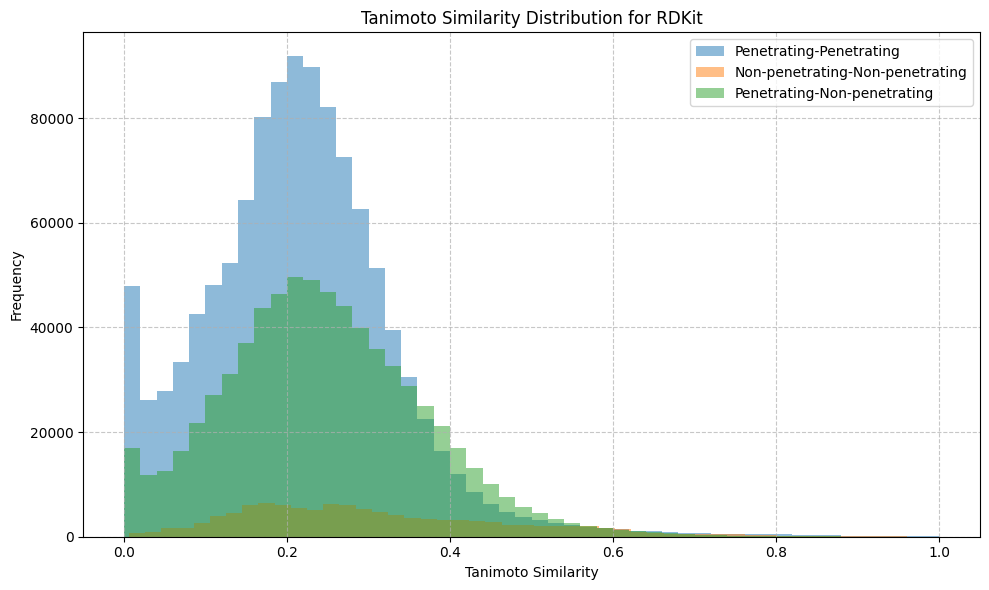

In [117]:
# Plot the top 3 combinations
best_combinations = results_df.sort_values('Weighted_Purity', ascending=False).head(3)
best_fp_alg = best_combinations.iloc[0]
best_fp_name = best_fp_alg['Fingerprint']
best_alg_name = best_fp_alg['Algorithm']

# Get the best fingerprint data and rerun the best algorithm
best_fp_data = fingerprint_types[best_fp_name]

# Special handling for SOM if it's the best
if best_alg_name == 'SOM':
    # Initialize and train SOM again
    som_dim = int(np.sqrt(2 * np.sqrt(len(best_fp_data))))
    som = MiniSom(x=som_dim, y=som_dim, input_len=best_fp_data.shape[1], 
                 sigma=1.0, learning_rate=0.5, 
                 random_seed=42)
    data_scaled = StandardScaler().fit_transform(best_fp_data)
    som.train(data_scaled, 1000, verbose=False)
    
    # Get BMUs and reduce to 2 clusters
    best_clusters = np.zeros(len(best_fp_data))
    for i, x in enumerate(data_scaled):
        winner = som.winner(x)
        best_clusters[i] = winner[0] * som_dim + winner[1]
    
    # Reduce to 2 clusters
    unique_labels = np.unique(best_clusters)
    if len(unique_labels) > 2:
        centroids = np.array([np.mean(data_scaled[best_clusters == label], axis=0) 
                            for label in unique_labels])
        kmeans_post = KMeans(n_clusters=2, random_state=42)
        kmeans_post.fit(centroids)
        label_mapping = kmeans_post.labels_
        best_clusters_2 = np.zeros_like(best_clusters)
        for i, label in enumerate(best_clusters):
            idx = np.where(unique_labels == label)[0][0]
            best_clusters_2[i] = label_mapping[idx]
        best_clusters = best_clusters_2
else:
    # Use the regular algorithm
    best_algorithm = clustering_algorithms[best_alg_name]
    best_clusters = best_algorithm.fit_predict(best_fp_data)

# Rest of the visualization code remains the same
print(f"\nVisualizing the best combination: {best_fp_name} with {best_alg_name}")

# Create a DataFrame for visualization
cluster_viz_df = pd.DataFrame({
    'tSNE_1': viz_df['tSNE_1'],
    'tSNE_2': viz_df['tSNE_2'],
    'Actual_Class': viz_df['PenetrationLabel'],
    'Predicted_Cluster': ["Cluster " + str(c) for c in best_clusters],
    'Drug_ID': viz_df['Drug_ID']
})

# Create subplots with 1 row and 2 columns
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=(
        'Actual BBB Penetration Classes', 
        f'Predicted Clusters using {best_fp_name} with {best_alg_name}'
    ),
    horizontal_spacing=0.1
)

# Add actual classes scatter plot
fig.add_trace(
    go.Scatter(
        x=cluster_viz_df['tSNE_1'],
        y=cluster_viz_df['tSNE_2'],
        mode='markers',
        marker=dict(
            size=8,
            color=viz_df['Penetration'],
            colorscale='RdBu_r',
            opacity=0.7,
            line=dict(width=0.5, color='DarkSlateGrey'),
            colorbar=dict(
                title="BBB Penetration",
                x=0.45,
                y=0.5,
                thickness=15,
                tickvals=[0, 1],
                ticktext=['Non-penetrating', 'Penetrating']
            ),
            showscale=True
        ),
        text=cluster_viz_df['Drug_ID'],
        hovertemplate='<b>Name:</b> %{text}<br><b>Actual Class:</b> %{marker.color}<extra></extra>',
        showlegend=False
    ),
    row=1, col=1
)

# Add predicted clusters scatter plot
fig.add_trace(
    go.Scatter(
        x=cluster_viz_df['tSNE_1'],
        y=cluster_viz_df['tSNE_2'],
        mode='markers',
        marker=dict(
            size=8,
            color=best_clusters,
            colorscale='Viridis',
            opacity=0.7,
            line=dict(width=0.5, color='DarkSlateGrey'),
            colorbar=dict(
                title="Predicted Cluster",
                x=1.0,
                y=0.5,
                thickness=15,
                tickvals=[0, 1],
                ticktext=['Cluster 0', 'Cluster 1']
            ),
            showscale=True
        ),
        text=cluster_viz_df['Drug_ID'],
        hovertemplate='<b>Name:</b> %{text}<br><b>Predicted Cluster:</b> %{marker.color}<extra></extra>',
        showlegend=False
    ),
    row=1, col=2
)

# Update layout
fig.update_layout(
    height=600,
    width=1200,
    title_text=f"BBB Penetration Clustering: Actual Classes vs. Predicted Clusters",
    title_font=dict(size=18),
    template="plotly_white",
    hoverlabel=dict(bgcolor="white", font_size=12),
    margin=dict(l=50, r=50, t=100, b=80)
)

# Update axis labels
fig.update_xaxes(title_text="t-SNE Component 1", row=1, col=1)
fig.update_yaxes(title_text="t-SNE Component 2", row=1, col=1)
fig.update_xaxes(title_text="t-SNE Component 1", row=1, col=2)
fig.update_yaxes(title_text="t-SNE Component 2", row=1, col=2)

# Show the interactive plot
fig.show()

# Analyze confusion matrix for the best combination
cluster0_majority = "Penetrating" if best_fp_alg['Cluster0_Penetrating'] > best_fp_alg['Cluster0_NonPenetrating'] else "Non-penetrating"
cluster1_majority = "Penetrating" if best_fp_alg['Cluster1_Penetrating'] > best_fp_alg['Cluster1_NonPenetrating'] else "Non-penetrating"

print(f"\nCluster Analysis for {best_fp_name} with {best_alg_name}:")
print(f"Cluster 0 is primarily {cluster0_majority} ({100*best_fp_alg['Purity_Cluster0']:.1f}% pure)")
print(f"Cluster 1 is primarily {cluster1_majority} ({100*best_fp_alg['Purity_Cluster1']:.1f}% pure)")
print(f"Overall weighted purity: {100*best_fp_alg['Weighted_Purity']:.1f}%")

# Confusion matrix-like analysis
print("\nCluster Distribution:")
print(f"                  | Penetrating | Non-penetrating | Total")
print(f"------------------+-------------+----------------+------")
print(f"Cluster 0         | {best_fp_alg['Cluster0_Penetrating']:11d} | {best_fp_alg['Cluster0_NonPenetrating']:14d} | {best_fp_alg['Cluster0_Penetrating'] + best_fp_alg['Cluster0_NonPenetrating']:5d}")
print(f"Cluster 1         | {best_fp_alg['Cluster1_Penetrating']:11d} | {best_fp_alg['Cluster1_NonPenetrating']:14d} | {best_fp_alg['Cluster1_Penetrating'] + best_fp_alg['Cluster1_NonPenetrating']:5d}")
print(f"------------------+-------------+----------------+------")
print(f"Total             | {best_fp_alg['Cluster0_Penetrating'] + best_fp_alg['Cluster1_Penetrating']:11d} | {best_fp_alg['Cluster0_NonPenetrating'] + best_fp_alg['Cluster1_NonPenetrating']:14d} | {best_fp_alg['Cluster0_Penetrating'] + best_fp_alg['Cluster1_Penetrating'] + best_fp_alg['Cluster0_NonPenetrating'] + best_fp_alg['Cluster1_NonPenetrating']:5d}")

# Summary and discussion
print("\nDetailed Discussion of Results:")
print("------------------------------")
print(f"1. Best Fingerprint: {best_fp_name}")
print(f"2. Best Algorithm: {best_alg_name}")
print(f"3. Adjusted Rand Index (similarity to ground truth): {best_fp_alg['ARI']:.3f}")
print(f"4. Silhouette Score (cluster quality): {best_fp_alg['Silhouette']:.3f}")
print(f"5. Davies-Bouldin Index (lower is better): {best_fp_alg['DBI']:.3f}")

# Tanimoto similarity discussion
print("\n6. Tanimoto Similarity Analysis for Best Fingerprint:")
print(f"   - Internal similarity among penetrating compounds: {tanimoto_stats[best_fp_name]['penetrating_internal_similarity']:.3f} ± {tanimoto_stats[best_fp_name]['pen_pen_std']:.3f}")
print(f"   - Internal similarity among non-penetrating compounds: {tanimoto_stats[best_fp_name]['nonpenetrating_internal_similarity']:.3f} ± {tanimoto_stats[best_fp_name]['nonpen_nonpen_std']:.3f}")
print(f"   - Between-class similarity: {tanimoto_stats[best_fp_name]['between_class_similarity']:.3f} ± {tanimoto_stats[best_fp_name]['between_class_std']:.3f}")

# Visualize Tanimoto similarity distributions for the best fingerprint type
plt.figure(figsize=(10, 6))
pen_pen_sims = [tanimoto_matrices[best_fp_name][i, j] for i in range(len(labels)) for j in range(i+1, len(labels)) if labels[i] == 1 and labels[j] == 1]
nonpen_nonpen_sims = [tanimoto_matrices[best_fp_name][i, j] for i in range(len(labels)) for j in range(i+1, len(labels)) if labels[i] == 0 and labels[j] == 0]
pen_nonpen_sims = [tanimoto_matrices[best_fp_name][i, j] for i in range(len(labels)) for j in range(len(labels)) if labels[i] == 1 and labels[j] == 0]

plt.hist(pen_pen_sims, alpha=0.5, bins=50, label='Penetrating-Penetrating')
plt.hist(nonpen_nonpen_sims, alpha=0.5, bins=50, label='Non-penetrating-Non-penetrating')
plt.hist(pen_nonpen_sims, alpha=0.5, bins=50, label='Penetrating-Non-penetrating')
plt.xlabel('Tanimoto Similarity')
plt.ylabel('Frequency')
plt.title(f'Tanimoto Similarity Distribution for {best_fp_name}')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [118]:
# Extract values from best_fp_alg dictionary
TP = best_fp_alg['Cluster0_Penetrating']  # True Positives
FP = best_fp_alg['Cluster0_NonPenetrating']  # False Positives
FN = best_fp_alg['Cluster1_Penetrating']  # False Negatives
TN = best_fp_alg['Cluster1_NonPenetrating']  # True Negatives

# Accuracy
accuracy = (TP + TN) / (TP + FP + TN + FN) if (TP + FP + TN + FN) != 0 else 0

# Precision (Positive Predictive Value)
precision = TP / (TP + FP) if (TP + FP) != 0 else 0

# Recall (Sensitivity / True Positive Rate)
recall = TP / (TP + FN) if (TP + FN) != 0 else 0

# F1-score
f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) != 0 else 0

# Print results
print("\nEvaluation Metrics:")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1_score:.4f}")



Evaluation Metrics:
Accuracy:  0.8071
Precision: 0.8244
Recall:    0.9480
F1-score:  0.8819




When clustering compounds using molecular fingerprints, the idea is to group molecules that share similar patterns of chemical features. Fingerprints encode these features (e.g., substructure presence or absence) into a bit vector (or some numerical representation), which can then be used with traditional clustering algorithms. Here, multiple experiments were carried out with different fingerprints (Morgan/ECFP4, MACCS Keys, AtomPair, Topological Torsion, RDKit) combined with different clustering algorithms (KMeans, DBSCAN, Agglomerative). The tables above summarizes each combination’s performance via a few common cluster validation and purity metrics.

---

### 1. Overview of Fingerprint methods taken from slides and internet

1. **Morgan (ECFP4) Fingerprints**  
    - Also known as Extended-Connectivity Fingerprints.  
    - Capture local environment of atoms with a certain radius, resulting in a circular substructure-based fingerprint.  
    - Often used for similarity searching and machine learning tasks because it is quite informative regarding local substructures.

2. **MACCS Keys**  
    - A set of 166 predefined structural keys (e.g., presence or absence of specific functional groups).  
    - Simpler and less detailed compared to Morgan fingerprints but very fast to compute.

3. **AtomPair Fingerprints**  
    - Encode atom environment and pairwise distances (in terms of bonds) between atoms.  
    - Capture 2D relationships between all atom pairs.

4. **Topological Torsion Fingerprints**  
    - Consider linear sequences (or “torsions”) of atoms in a molecule.  
    - More focused on specific paths in the topology (i.e., the ring and chain structure).

5. **RDKit Fingerprint**  
    - A default topological fingerprint in RDKit that applies a path-based approach.  
    - Similar in spirit to path-based substructure keys, capturing presence/absence of certain bond sequences.

Each fingerprint type represents a different perspective on molecular structure. This can lead to varying clustering behavior and different separation of chemical space.

---

### 2. Overview of Clustering Algorithms Tested

1. **KMeans**  
    - Partitions the data into a specified number of clusters (k).  
    - Minimizes within-cluster variance.  
    - Sensitive to initial starting points (centroids) and to data scaling.

2. **DBSCAN**  
    - Density-based; forms clusters around dense regions of points.  
    - Points in low-density areas are labeled as noise (outliers).  
    - Parameters (ε-neighborhood, min_samples) must be tuned carefully, especially with sparse data like fingerprints.

3. **Agglomerative (Hierarchical) Clustering**  
    - Builds a hierarchy of clusters by merging them step by step.  
    - The choice of linkage (e.g., average, complete, ward) affects which points or clusters get merged first.  
    - Often more flexible but can be slower for very large datasets.

4. **Self-Organizing Maps (SOM)**

    - A Self-Organizing Map was also applied to the data. Although SOM achieved a very high silhouette score, the resulting clusters were extremely unbalanced, with nearly all molecules being assigned to  cluster 0. This imbalance limits its practical utility for distinguishing compound classes.

---

### 3. Performance Metrics

- **Silhouette Score**  
  Ranges from –1 to +1; higher scores indicate more distinct separation between clusters vs. neighboring clusters.  
  In this context, values around 0.10–0.20 typically suggest moderate or weak but still distinguishable clusters.

- **Adjusted Rand Index (ARI)**  
  Compares clustering assignments to ground-truth labels.  
  Ranges from –1 to +1; 0 indicates random assignment, and +1 is perfect agreement.

- **Davies–Bouldin Index (DBI)**  
  Evaluates average “similarity” between clusters, using distance metrics.  
  Lower values are better because they indicate a clearer separation among clusters.

- **Purity / Weighted Purity**  
  Purity is an intuitive measure in a supervised context to see how “pure” (homogeneous) a cluster is with respect to a known label (e.g., "Penetrating" vs. "Non-penetrating").  
  Weighted purity gives an overall measure, taking into account the size of each cluster.

---

### 4. Notable Observations in the Results

1. **Best Fingerprint–Algorithm Pair**  
    - The results show that the combination of **RDKit fingerprint** with **Agglomerative clustering** achieved a relatively higher ARI (0.266) compared to other runs.  
    - Its silhouette score (0.147) is not very large in absolute terms but is still higher than or comparable to some other pairs.  
    - The DBI of 2.106 is also in a reasonable range (lower than some other methods).

2. **Cluster Purity**  
    - Cluster 0 is primarily Penetrating (82.4% pure).  
    - Cluster 1 is primarily Non-penetrating (68.7% pure).  (This is due also tho the lower number of Non-Penetrating moleculs in the dataset)
    - The **weighted purity** is ~80.7%. This indicates that the cluster assignments align decently with the known Penetrating/Non-penetrating labels.

3. **Comparisons with Other Fingerprints**  
    - Some other fingerprints (e.g., MACCS Keys with DBSCAN) exhibit very low or even invalid scores (like a silhouette of –1.000 and DBI = inf). This can happen when DBSCAN fails to form meaningful clusters (perhaps all or most data points become outliers, or only a single cluster emerges).  
    - Morgan (ECFP4) did show some moderate results as well, but not as strong as RDKit + Agglomerative in terms of ARI or silhouette.

4. **Interpretation of the Silhouette and ARI Values**  
    - The silhouette values here are not very high, suggesting the inherent nature of the fingerprint-based chemical space might not be strongly separable by these clustering methods for the underlying labels.  
    - The ARI around 0.266 (for RDKit + Agglomerative) does show some consistency with the “penetration” labels, but it’s not extremely high, indicating partial overlap or complexity in the data.  
    - Still, within the scope of this dataset, ~0.266 is a respectable ARI given that we are clustering on structural fingerprints alone.

---

### 5. Why RDKit + Agglomerative Might Work Better

- **RDKit Fingerprint**  
  A relatively balanced path-based approach that captures common substructure motifs without overemphasizing local neighborhoods or specific ring systems.

- **Agglomerative Clustering**  
  Hierarchical methods can be more flexible, especially if the data forms smaller substructures or irregular shapes.  
  The “average” linkage merges clusters by considering the average distance between all pairs in the two clusters, which can yield more balanced groupings in chemical space.

---

### 6. Tanimoto Similarity Analysis for Best Fingerprint

- Internal similarity among penetrating compounds: 0.215 ± 0.117
- Internal similarity among non-penetrating compounds: 0.314 ± 0.171
- Between-class similarity: 0.245 ± 0.123

**Considerations:**
The higher internal similarity among non-penetrating compounds (0.314 ± 0.171) compared to penetrating ones (0.215 ± 0.117) suggests that the non-penetrating molecules exhibit **lower structural diversity and form a more localized group within the RDKit fingerprint space.** Penetrating molecules appear more structurally diverse, showing lower internal similarity. The moderate between-class similarity (0.245) reflects partial overlap in chemical features across the two sets. These patterns underscore that differences in 2D structure alone can help distinguish penetration properties to some extent, but not perfectly, given the inherent variation in real-world physicochemical behaviors.

---

### Issues with Clustering with Fingerprints Only
  Clustering purely on structural (topological) information tends to group molecules by how they look in a 2D sense (substructures, ring systems, functional groups).  
  However, the *real-world property* of “penetration” (in this case) can also depend on factors like 3D conformation, solubility, or subtle interactions that may not be fully captured by a 2D fingerprint.  
  This explains why the best ARI is moderate rather than near-perfect.


---

### 5) Using interpretable features

In [119]:
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score, adjusted_rand_score
from sklearn.metrics import adjusted_rand_score as adjusted_rand_index
from plotly.subplots import make_subplots
import seaborn as sns

import plotly.graph_objects as go
import matplotlib.pyplot as plt

# Select interpretable features for clustering
selected_features = ['MW', 'LogP', 'HBD', 'HBA', 'TPSA', 'Rotatable_Bonds', 
                     'Aromatic_Rings', 'Heavy_Atoms', 'Fraction_CSP3']

# Extract features and labels
X = df[selected_features].values
y = df['Y'].values

# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Define clustering algorithms and parameters to try
algorithms = {
    'KMeans': {
        'model': KMeans,
        'params': {
            'n_clusters': [2],
            'random_state': [42],
            'n_init': [10]
        }
    },
    'DBSCAN': {
        'model': DBSCAN,
        'params': {
            'eps': [0.3, 0.5, 0.7, 1.0, 1.5, 2.0],
            'min_samples': [5, 10, 20, 30, 50]
        }
    },
    'Agglomerative': {
        'model': AgglomerativeClustering,
        'params': {
            'n_clusters': [2],
            'linkage': ['ward', 'complete', 'average']
        }
    }
}

# Function to evaluate clustering
def evaluate_clustering(labels_true, labels_pred):
    # Handle noise points in DBSCAN (-1 labels)
    if -1 in labels_pred:
        mask = labels_pred != -1
        if sum(mask) <= 1:  # Need at least 2 points for metrics
            return -1, float('inf'), 0, 0
        
        # Calculate metrics only on non-noise points
        sil = silhouette_score(X_scaled[mask], labels_pred[mask]) if len(set(labels_pred[mask])) > 1 else -1
        dbi = davies_bouldin_score(X_scaled[mask], labels_pred[mask]) if len(set(labels_pred[mask])) > 1 else float('inf')
        ari = adjusted_rand_index(labels_true[mask], labels_pred[mask])
        
        # Calculate chi-square statistic for cluster-class relationship
        n_clusters = len(set(labels_pred[mask]))
        chi = 0
        for c in range(n_clusters):
            cluster_mask = labels_pred[mask] == c
            if sum(cluster_mask) > 0:
                penetrating = sum((labels_pred[mask] == c) & (labels_true[mask] == 1))
                non_penetrating = sum((labels_pred[mask] == c) & (labels_true[mask] == 0))
                expected_pen = sum(cluster_mask) * sum(labels_true[mask] == 1) / len(labels_true[mask])
                expected_non = sum(cluster_mask) * sum(labels_true[mask] == 0) / len(labels_true[mask])
                
                if expected_pen > 0 and expected_non > 0:
                    chi += (penetrating - expected_pen)**2 / expected_pen
                    chi += (non_penetrating - expected_non)**2 / expected_non
    else:
        # Calculate metrics for all points
        sil = silhouette_score(X_scaled, labels_pred) if len(set(labels_pred)) > 1 else -1
        dbi = davies_bouldin_score(X_scaled, labels_pred) if len(set(labels_pred)) > 1 else float('inf')
        ari = adjusted_rand_index(labels_true, labels_pred)
        
        # Calculate chi-square statistic
        n_clusters = len(set(labels_pred))
        chi = 0
        for c in range(n_clusters):
            cluster_mask = labels_pred == c
            if sum(cluster_mask) > 0:
                penetrating = sum((labels_pred == c) & (labels_true == 1))
                non_penetrating = sum((labels_pred == c) & (labels_true == 0))
                expected_pen = sum(cluster_mask) * sum(labels_true == 1) / len(labels_true)
                expected_non = sum(cluster_mask) * sum(labels_true == 0) / len(labels_true)
                
                if expected_pen > 0 and expected_non > 0:
                    chi += (penetrating - expected_pen)**2 / expected_pen
                    chi += (non_penetrating - expected_non)**2 / expected_non
    
    # Calculate weighted purity
    unique_clusters = set(labels_pred)
    if -1 in unique_clusters:
        unique_clusters.remove(-1)
    
    total_points = sum(labels_pred != -1) if -1 in labels_pred else len(labels_pred)
    weighted_purity = 0
    
    cluster_info = {}
    
    for c in unique_clusters:
        cluster_mask = labels_pred == c
        cluster_size = sum(cluster_mask)
        
        if cluster_size > 0:
            cluster_penetrating = sum(cluster_mask & (labels_true == 1))
            cluster_nonpenetrating = sum(cluster_mask & (labels_true == 0))
            
            # Determine majority class in this cluster
            if cluster_penetrating > cluster_nonpenetrating:
                purity = cluster_penetrating / cluster_size
                majority_class = 'Penetrating'
            else:
                purity = cluster_nonpenetrating / cluster_size
                majority_class = 'Non-penetrating'
            
            # Store cluster information
            cluster_info[c] = {
                'size': cluster_size,
                'penetrating': cluster_penetrating,
                'non_penetrating': cluster_nonpenetrating,
                'purity': purity,
                'majority_class': majority_class
            }
            
            # Add to weighted purity
            weighted_purity += purity * (cluster_size / total_points)
    
    return sil, dbi, chi, ari, weighted_purity, cluster_info

# Run clustering algorithms with different parameters
results = []

print("Evaluating clustering algorithms with different parameters...")
for alg_name, alg_info in algorithms.items():
    model_class = alg_info['model']
    param_grid = alg_info['params']
    
    # Generate all parameter combinations
    param_combinations = []
    param_keys = list(param_grid.keys())
    
    def generate_combinations(current_combo, depth):
        if depth == len(param_keys):
            param_combinations.append(current_combo.copy())
            return
        
        key = param_keys[depth]
        for value in param_grid[key]:
            current_combo[key] = value
            generate_combinations(current_combo, depth + 1)
    
    generate_combinations({}, 0)
    
    # Try each parameter combination
    for params in param_combinations:
        try:
            # Create and fit the model
            model = model_class(**params)
            cluster_labels = model.fit_predict(X_scaled)
            
            # Calculate number of clusters (excluding noise points)
            n_clusters = len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)
            
            # Skip if less than 2 clusters
            if n_clusters < 2:
                continue
            
            # Evaluate clustering
            sil, dbi, chi, ari, weighted_purity, cluster_info = evaluate_clustering(y, cluster_labels)
            
            # Create a result dictionary
            result = {
                'algorithm': alg_name,
                'params': params,
                'n_clusters': n_clusters,
                'silhouette': sil,
                'dbi': dbi,
                'chi': chi,
                'ari': ari,
                'weighted_purity': weighted_purity,
                'clusters': cluster_info,
                'labels': cluster_labels
            }
            
            results.append(result)
            
            # Print brief progress
            print(f"{alg_name} with {n_clusters} clusters - Silhouette: {sil:.3f}, ARI: {ari:.3f}, Weighted Purity: {weighted_purity:.3f}")
            
        except Exception as e:
            print(f"Error with {alg_name} and params {params}: {str(e)}")
            continue

# Convert results to DataFrame for easier analysis
results_df = pd.DataFrame([
    {
        'algorithm': r['algorithm'],
        **{f"param_{k}": v for k, v in r['params'].items()},
        'n_clusters': r['n_clusters'],
        'silhouette': r['silhouette'],
        'dbi': r['dbi'],
        'chi': r['chi'],
        'ari': r['ari'],
        'weighted_purity': r['weighted_purity']
    } for r in results
])

# Add a more correct combined score (higher is better)
# Normalize all metrics to [0, 1] where possible, and use weights reflecting their importance.
# Silhouette, ARI, weighted_purity: already in [0, 1]
# DBI: lower is better, so invert and normalize
# CHI: higher is better, but can be unbounded, so normalize by max in results

# Avoid division by zero for DBI and CHI normalization
dbi_max = results_df['dbi'].replace([np.inf, -np.inf], np.nan).max()
dbi_min = results_df['dbi'].replace([np.inf, -np.inf], np.nan).min()
chi_max = results_df['chi'].replace([np.inf, -np.inf], np.nan).max()
chi_min = results_df['chi'].replace([np.inf, -np.inf], np.nan).min()

# Normalize DBI: lower is better, so (max - value) / (max - min)
results_df['dbi_norm'] = (dbi_max - results_df['dbi']) / (dbi_max - dbi_min) if dbi_max != dbi_min else 0.0
# Normalize CHI: (value - min) / (max - min)
results_df['chi_norm'] = (results_df['chi'] - chi_min) / (chi_max - chi_min) if chi_max != chi_min else 0.0

# Define weights for each metric (sum to 1.0 for interpretability)
w_sil = 0.25
w_ari = 0.20
w_purity = 0.25
w_dbi = 0.15
w_chi = 0.15

results_df['combined_score'] = (
    w_sil * results_df['silhouette'] +
    w_ari * results_df['ari'] +
    w_purity * results_df['weighted_purity'] +
    w_dbi * results_df['dbi_norm'] +
    w_chi * results_df['chi_norm']
)

# Display top results sorted by combined score
top_results = results_df.sort_values('combined_score', ascending=False)
print("\nclustering configurations by combined score:")
top_results

Evaluating clustering algorithms with different parameters...
KMeans with 2 clusters - Silhouette: 0.478, ARI: 0.318, Weighted Purity: 0.827
DBSCAN with 6 clusters - Silhouette: 0.778, ARI: -0.009, Weighted Purity: 0.933
DBSCAN with 37 clusters - Silhouette: 0.198, ARI: 0.009, Weighted Purity: 0.958
DBSCAN with 11 clusters - Silhouette: 0.412, ARI: 0.010, Weighted Purity: 0.955
DBSCAN with 16 clusters - Silhouette: 0.099, ARI: 0.031, Weighted Purity: 0.896
DBSCAN with 11 clusters - Silhouette: 0.190, ARI: 0.050, Weighted Purity: 0.919
DBSCAN with 6 clusters - Silhouette: 0.295, ARI: 0.012, Weighted Purity: 0.945
DBSCAN with 2 clusters - Silhouette: 0.478, ARI: 0.057, Weighted Purity: 0.950
DBSCAN with 12 clusters - Silhouette: 0.076, ARI: 0.021, Weighted Purity: 0.839
DBSCAN with 7 clusters - Silhouette: 0.157, ARI: 0.007, Weighted Purity: 0.852
DBSCAN with 6 clusters - Silhouette: 0.167, ARI: -0.005, Weighted Purity: 0.868
DBSCAN with 5 clusters - Silhouette: 0.142, ARI: 0.007, Weight

,algorithm,param_n_clusters,param_random_state,param_n_init,n_clusters,silhouette,dbi,chi,ari,weighted_purity,param_eps,param_min_samples,param_linkage,dbi_norm,chi_norm,combined_score
16,Agglomerative,2.0,NaN,NaN,2,0.476234,1.127760,497.508049,0.348161,0.836962,NaN,NaN,ward,0.356659,1.000000,0.601430
1,DBSCAN,NaN,NaN,NaN,6,0.778438,0.270352,9.935065,-0.009100,0.933333,0.3,5.0,NaN,1.000000,0.011137,0.577793
0,KMeans,2.0,42.0,10.0,2,0.478197,1.106241,426.656143,0.318114,0.826835,NaN,NaN,NaN,0.372805,0.856303,0.574247
14,DBSCAN,NaN,NaN,NaN,2,0.688336,0.316904,30.289472,0.027690,0.801851,1.5,10.0,NaN,0.965071,0.052419,0.530708
18,Agglomerative,2.0,NaN,NaN,2,0.808846,0.478768,12.692373,0.008762,0.762025,NaN,NaN,average,0.843619,0.016729,0.523523
17,Agglomerative,2.0,NaN,NaN,2,0.733020,0.615905,26.360421,0.022567,0.764557,NaN,NaN,complete,0.740720,0.044450,0.496683
13,DBSCAN,NaN,NaN,NaN,5,0.480059,0.583152,129.255522,0.096899,0.799788,1.5,5.0,NaN,0.765296,0.253135,0.492106
15,DBSCAN,NaN,NaN,NaN,3,0.504699,0.492749,81.928271,0.063185,0.783351,2.0,10.0,NaN,0.833128,0.157149,0.483191
7,DBSCAN,NaN,NaN,NaN,2,0.477756,0.805561,4.443755,0.057313,0.950450,0.7,30.0,NaN,0.598415,0.000000,0.458276
3,DBSCAN,NaN,NaN,NaN,11,0.411905,0.794927,20.789406,0.010207,0.954774,0.5,10.0,NaN,0.606394,0.033151,0.439643


In [120]:


# Select the best algorithm
best_result = results[results_df['combined_score'].argmax()]
print("\nBest clustering algorithm:", best_result['algorithm'])
print("Parameters:", best_result['params'])
print(f"Number of clusters: {best_result['n_clusters']}")
print(f"Silhouette score: {best_result['silhouette']:.3f}")
print(f"Adjusted Rand Index: {best_result['ari']:.3f}")
print(f"Weighted purity: {best_result['weighted_purity']:.3f}")

# Analyze the best clustering
best_labels = best_result['labels']

# Plot t-SNE visualization of clusters
fig = make_subplots(
    rows=1, cols=3, 
    subplot_titles=(
        'Actual BBB Penetration Classes', 
        f'Predicted Clusters ({best_result["algorithm"]} with {best_result["n_clusters"]} clusters)',
        'Cluster Feature Importance'
    ),
    specs=[[{'type': 'scatter'}, {'type': 'scatter'}, {'type': 'heatmap'}]],
    horizontal_spacing=0.08
)

# Plot 1: Actual classes
fig.add_trace(
    go.Scatter(
        x=viz_df['tSNE_1'],
        y=viz_df['tSNE_2'],
        mode='markers',
        marker=dict(
            size=7,
            color=viz_df['Penetration'],
            colorscale='RdBu_r',
            opacity=0.7,
            line=dict(width=0.5, color='DarkSlateGrey'),
            colorbar=dict(
                title="BBB Penetration",
                x=0.3,
                y=0.5,
                thickness=15,
                tickvals=[0, 1],
                ticktext=['Non-penetrating', 'Penetrating']
            ),
            showscale=True
        ),
        text=viz_df['Drug_ID'],
        hovertemplate='<b>Name:</b> %{text}<br><b>Actual Class:</b> %{marker.color}<extra></extra>',
        showlegend=False
    ),
    row=1, col=1
)

# Plot 2: Predicted clusters
fig.add_trace(
    go.Scatter(
        x=viz_df['tSNE_1'],
        y=viz_df['tSNE_2'],
        mode='markers',
        marker=dict(
            size=7,
            color=best_labels,
            colorscale='Viridis',
            opacity=0.7,
            line=dict(width=0.5, color='DarkSlateGrey'),
            colorbar=dict(
                title="Cluster",
                x=0.65,
                y=0.5,
                thickness=15,
                tickvals=list(range(best_result['n_clusters'])),
                ticktext=[f"Cluster {i}" for i in range(best_result['n_clusters'])]
            ),
            showscale=True
        ),
        text=viz_df['Drug_ID'],
        hovertemplate='<b>Name:</b> %{text}<br><b>Cluster:</b> %{marker.color}<extra></extra>',
        showlegend=False
    ),
    row=1, col=2
)

# Calculate feature importance for each cluster
cluster_feature_means = []
for i in range(best_result['n_clusters']):
    if i in best_result['clusters']:  # Skip noise points if DBSCAN
        cluster_mask = best_labels == i
        cluster_data = X_scaled[cluster_mask]
        cluster_mean = np.mean(cluster_data, axis=0)
        cluster_feature_means.append(cluster_mean)

# Create heatmap data
feature_importance = np.array(cluster_feature_means)

# Plot 3: Feature importance heatmap
fig.add_trace(
    go.Heatmap(
        z=feature_importance,
        x=selected_features,
        y=[f"Cluster {i}" for i in range(len(cluster_feature_means))],
        colorscale='RdBu_r',
        colorbar=dict(title="Z-score", x=1.0),
        hoverongaps=False,
        hovertemplate='<b>Cluster:</b> %{y}<br><b>Feature:</b> %{x}<br><b>Value:</b> %{z:.2f}<extra></extra>'
    ),
    row=1, col=3
)

# Update layout
fig.update_layout(
    height=600,
    width=1800,
    title_text=f"BBB Penetration Clustering using Interpretable Features",
    template="plotly_white",
    hoverlabel=dict(bgcolor="white", font_size=12),
)

# Update axes
fig.update_xaxes(title_text="t-SNE Component 1", row=1, col=1)
fig.update_yaxes(title_text="t-SNE Component 2", row=1, col=1)
fig.update_xaxes(title_text="t-SNE Component 1", row=1, col=2)
fig.update_yaxes(title_text="t-SNE Component 2", row=1, col=2)
fig.update_xaxes(title_text="Features", row=1, col=3)
fig.update_yaxes(title_text="Clusters", row=1, col=3)

# Show the plot
fig.show()

# Calculate cluster statistics for interpretability
print("\nCluster Analysis:")
for cluster_id, info in best_result['clusters'].items():
    print(f"\nCluster {cluster_id} ({info['size']} molecules, {info['purity']*100:.1f}% pure):")
    print(f"  Majority class: {info['majority_class']}")
    print(f"  Penetrating molecules: {info['penetrating']} ({info['penetrating']/info['size']*100:.1f}%)")
    print(f"  Non-penetrating molecules: {info['non_penetrating']} ({info['non_penetrating']/info['size']*100:.1f}%)")
    
    # Get feature means for this cluster
    mask = best_labels == cluster_id
    cluster_data = df.loc[mask, selected_features]
    cluster_means = cluster_data.mean()
    
    print("  Feature averages:")
    for feature, mean_val in cluster_means.items():
        global_mean = df[feature].mean()
        diff = mean_val - global_mean
        direction = "higher" if diff > 0 else "lower"
        print(f"    {feature}: {mean_val:.2f} ({abs(diff/global_mean)*100:.1f}% {direction} than average)")

# Confusion matrix-like analysis
print("\nCluster Distribution:")
print(f"                  | Penetrating | Non-penetrating | Total")
print(f"------------------+-------------+----------------+------")
for cluster_id, info in best_result['clusters'].items():
    print(f"Cluster {cluster_id:<3}       | {info['penetrating']:11d} | {info['non_penetrating']:14d} | {info['size']:5d}")
print(f"------------------+-------------+----------------+------")
print(f"Total             | {sum(info['penetrating'] for info in best_result['clusters'].values()):11d} | " +
      f"{sum(info['non_penetrating'] for info in best_result['clusters'].values()):14d} | " +
      f"{sum(info['size'] for info in best_result['clusters'].values()):5d}")


Best clustering algorithm: Agglomerative
Parameters: {'n_clusters': 2, 'linkage': 'ward'}
Number of clusters: 2
Silhouette score: 0.476
Adjusted Rand Index: 0.348
Weighted purity: 0.837



Cluster Analysis:

Cluster 0 (1753 molecules, 83.6% pure):
  Majority class: Penetrating
  Penetrating molecules: 1466 (83.6%)
  Non-penetrating molecules: 287 (16.4%)
  Feature averages:
    MW: 316.18 (8.8% lower than average)
    LogP: 2.61 (13.3% higher than average)
    HBD: 1.13 (27.6% lower than average)
    HBA: 3.75 (18.8% lower than average)
    TPSA: 55.87 (22.0% lower than average)
    Rotatable_Bonds: 3.77 (10.4% lower than average)
    Aromatic_Rings: 1.41 (0.2% higher than average)
    Heavy_Atoms: 22.13 (8.5% lower than average)
    Fraction_CSP3: 0.45 (2.3% lower than average)

Cluster 1 (222 molecules, 84.2% pure):
  Majority class: Non-penetrating
  Penetrating molecules: 35 (15.8%)
  Non-penetrating molecules: 187 (84.2%)
  Feature averages:
    MW: 588.09 (69.6% higher than average)
    LogP: -0.12 (105.2% lower than average)
    HBD: 4.98 (217.7% higher than average)
    HBA: 11.47 (148.3% higher than average)
    TPSA: 196.26 (173.9% higher than average)
    Rot

In [121]:
# Compute evaluation metrics from cluster distribution
TP = best_result['clusters'][0]['penetrating']  # True Positives
FP = best_result['clusters'][0]['non_penetrating']  # False Positives
FN = best_result['clusters'][1]['penetrating']  # False Negatives
TN = best_result['clusters'][1]['non_penetrating']  # True Negatives

# Accuracy
accuracy = (TP + TN) / (TP + FP + TN + FN)

# Precision (Positive Predictive Value)
precision = TP / (TP + FP) if (TP + FP) != 0 else 0

# Recall (Sensitivity / True Positive Rate)
recall = TP / (TP + FN) if (TP + FN) != 0 else 0

# F1-score
f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) != 0 else 0

# Print results
print("\nEvaluation Metrics:")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1_score:.4f}")



Evaluation Metrics:
Accuracy:  0.8370
Precision: 0.8363
Recall:    0.9767
F1-score:  0.9010


#### Pros of Using Molecular Features
1. **Interpretability**: Molecular features such as molecular weight (MW), LogP, hydrogen bond donors (HBD), and topological polar surface area (TPSA) are easily interpretable and provide clear insights into the chemical properties that influence blood-brain barrier (BBB) penetration.
2. **Feature Relevance**: The clustering results highlight the importance of specific molecular features in distinguishing between penetrating and non-penetrating molecules. For example, lower MW, higher LogP, and fewer HBDs are associated with penetrating molecules.
3. **Actionable Insights**: The feature averages for each cluster provide actionable insights for drug design. For instance, to improve BBB penetration, one might aim to design molecules with lower MW, moderate LogP, and fewer HBDs.

#### Cons of Using Molecular Features
1. **Dimensionality**: Molecular features may not capture the full complexity of molecular structures. High-dimensional fingerprints can encode more detailed structural information, which might be lost when using a limited set of molecular features.
2. **Non-linearity**: Molecular features may not capture non-linear relationships between structural elements and BBB penetration. Fingerprints, which encode substructures and patterns, might better capture these non-linear relationships.
3. **Feature Selection**: The choice of molecular features can significantly impact the clustering results. Inappropriate feature selection might lead to suboptimal clustering performance.

### Comparison with Fingerprint-Based Clustering
- **Silhouette Score**: The silhouette score for molecular feature-based clustering (0.476) is higher than some fingerprint-based clustering results, indicating better-defined clusters.
- **ARI**: The ARI for molecular feature-based clustering (0.348) is higher than most fingerprint-based clustering results, suggesting better alignment with the ground truth labels.
- **Weighted Purity**: The weighted purity (0.837) is comparable to the best fingerprint-based clustering results, indicating a high degree of homogeneity within clusters.

### Conclusion
Using molecular features for clustering provides interpretable and actionable insights into the properties that influence BBB penetration. While molecular features offer clear advantages in terms of interpretability, they may not capture the full complexity of molecular structures compared to high-dimensional fingerprints. The choice between molecular features and fingerprints should be guided by the specific goals of the analysis and the nature of the dataset.

# Model Selection 

In [122]:
# Load train, valid, and test datasets from the BBB_Martins folder
train_df = pd.read_csv("BBB_Martins/train.csv")
valid_df = pd.read_csv("BBB_Martins/valid.csv")
test_df = pd.read_csv("BBB_Martins/test.csv")

train_df = clean_and_deduplicate_smiles(train_df)
valid_df = clean_and_deduplicate_smiles(valid_df)
test_df = clean_and_deduplicate_smiles(test_df)

print("Train shape:", train_df.shape)
print("Valid shape:", valid_df.shape)
print("Test shape:", test_df.shape)


Train shape: (1400, 3)
Valid shape: (203, 3)
Test shape: (405, 3)


In [123]:
def calculate_physchem_features(df_input, smiles_col='Drug'):
    """
    Calculates physicochemical features for molecules in a DataFrame 
    and appends them as new columns.

    Args:
        df_input (pd.DataFrame): Input DataFrame containing a column with SMILES strings.
        smiles_col (str): The name of the column containing SMILES strings.

    Returns:
        pd.DataFrame: Original DataFrame with the calculated physicochemical properties
                      appended as new columns. Properties that could not be calculated
                      (e.g., due to invalid SMILES) will have NaN values.
    """
    feature_names = [
        'MW', 'LogP', 'HBD', 'HBA', 'TPSA', 'Rotatable_Bonds',
        'Aromatic_Rings', 'Heavy_Atoms', 'Fraction_CSP3', 'QED'
    ]
    features_list = []

    print(f"Calculating physicochemical features for {len(df_input)} molecules...")

    for smiles in df_input[smiles_col]:
        mol = Chem.MolFromSmiles(smiles)
        props = {}

        if mol:
            try:
                props['MW']              = Descriptors.MolWt(mol)
                props['LogP']            = Descriptors.MolLogP(mol)
                props['HBD']             = Descriptors.NumHDonors(mol)
                props['HBA']             = Descriptors.NumHAcceptors(mol)
                props['TPSA']            = MolSurf.TPSA(mol)
                props['Rotatable_Bonds'] = Descriptors.NumRotatableBonds(mol)
                props['Aromatic_Rings']  = Descriptors.NumAromaticRings(mol)
                props['Heavy_Atoms']     = mol.GetNumHeavyAtoms()
                props['Fraction_CSP3']   = Descriptors.FractionCSP3(mol)
                props['QED']             = Descriptors.qed(mol)
            except Exception as e:
                print(f"Warning: Could not calculate features for SMILES '{smiles}': {e}")
                for name in feature_names:
                    props[name] = np.nan
        else:
            print(f"Warning: Could not parse SMILES: '{smiles}'")
            for name in feature_names:
                props[name] = np.nan

        features_list.append(props)

    # Build a DataFrame of features and align it with the input index
    features_df = pd.DataFrame(features_list, index=df_input.index)

    # Concatenate the original data with the new feature columns
    augmented_df = pd.concat([df_input, features_df], axis=1)

    print("Feature calculation complete. Returning augmented DataFrame.")
    return augmented_df

In [124]:
# Example Usage (assuming train_df, valid_df, test_df are loaded):
df_train_features = calculate_physchem_features(train_df)
df_valid_features = calculate_physchem_features(valid_df)
df_test_features = calculate_physchem_features(test_df)
df_train_features

Calculating physicochemical features for 1400 molecules...
Feature calculation complete. Returning augmented DataFrame.
Calculating physicochemical features for 203 molecules...
Feature calculation complete. Returning augmented DataFrame.
Calculating physicochemical features for 405 molecules...
Feature calculation complete. Returning augmented DataFrame.


,Drug_ID,Drug,Y,MW,LogP,HBD,HBA,TPSA,Rotatable_Bonds,Aromatic_Rings,Heavy_Atoms,Fraction_CSP3,QED
0,Terbutylchlorambucil,CC(C)(C)OC(=O)CCCc1ccc(N(CCCl)CCCl)cc1,1,360.325,4.63500,0,3,29.54,9,1,23,0.611111,0.474821
1,40730,CC1COc2c(N3CCN(C)CC3)c(F)cc3c(=O)c(C(=O)O)cn1c23,1,361.373,1.54400,1,6,75.01,2,2,26,0.444444,0.874740
2,cloxacillin,Cc1onc(-c2ccccc2Cl)c1C(=O)N[C@@H]1C(=O)N2[C@@H...,1,435.889,2.54872,2,6,112.74,4,2,29,0.368421,0.709265
3,cefoperazone,CCN1CCN(C(=O)N[C@@H](C(=O)N[C@@H]2C(=O)N3C(C(=...,1,645.680,-1.11200,4,13,220.26,9,2,44,0.400000,0.144538
4,rolitetracycline,CN(C)[C@@H]1C(=O)/C(=C(/O)NCN2CCCC2)C(=O)[C@@]...,1,527.574,0.31320,6,11,170.87,4,1,38,0.518519,0.137829
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1416,licostinel,O=c1[nH]c2cc(Cl)c(Cl)c([N+](=O)[O-])c2[nH]c1=O,1,276.035,1.43140,2,4,108.86,1,2,17,0.000000,0.466075
1417,ademetionine(adenosyl-methionine),C[S+](CC[C@H](N)C(=O)[O-])C[C@H]1O[C@@H](n2cnc...,1,398.445,-3.25690,4,11,185.46,7,2,27,0.600000,0.344970
1418,mesocarb,CC(Cc1ccccc1)n1cc([N-]C(=O)Nc2ccccc2)[o+]n1,1,322.368,4.79820,1,3,72.32,5,3,24,0.166667,0.685827
1419,tofisoline,CCc1c(C)[n+]([NH-])c(-c2ccc(OC)c(OC)c2)c2cc(OC...,1,382.460,4.51482,0,4,64.60,6,3,28,0.318182,0.588327


In [125]:
df_valid_features

,Drug_ID,Drug,Y,MW,LogP,HBD,HBA,TPSA,Rotatable_Bonds,Aromatic_Rings,Heavy_Atoms,Fraction_CSP3,QED
0,timiperone,O=C(CCCN1CCC(n2c(=S)[nH]c3ccccc32)CC1)c1ccc(F)cc1,1,397.519,5.13799,1,4,41.03,6,3,28,0.363636,0.462591
1,compound 32,O=[N+]([O-])C1=CC=NC1NCCSCc1ccccn1,1,278.337,1.47550,1,6,80.42,7,1,19,0.333333,0.463945
2,ketorfanol,O=C1CC[C@H]2[C@H]3Cc4cccc(O)c4[C@@]2(CCN3CC2CC...,1,311.425,3.03960,1,3,40.54,2,1,23,0.650000,0.912450
3,phenytoin,O=C1NC(=O)C(c2ccccc2)(c2ccccc2)N1,1,252.273,1.76960,2,2,58.20,2,2,19,0.066667,0.800195
4,fluocortin,CCCCOC(=O)C(=O)C1C(C)CC2C3CC(F)C4=CC(=O)C=CC4(...,1,446.559,3.98770,1,5,80.67,5,0,32,0.730769,0.392420
...,...,...,...,...,...,...,...,...,...,...,...,...,...
198,sibopirdine,O.c1cncc(CC2(Cc3ccncc3)c3cccnc3-c3ncccc32)c1,1,368.440,3.19380,0,4,83.06,4,4,28,0.130435,0.553722
199,Sulfadiazine,Nc1ccc(S(=O)(=O)Nc2ncccn2)cc1,1,250.283,0.85960,2,5,97.97,3,2,17,0.000000,0.787140
200,2-methylpropanol,CC(C)CO,1,74.123,0.63470,1,1,20.23,1,0,5,1.000000,0.483480
201,thialbarbital,C=CCC1(C2C=CCCC2)C(=O)NC(=S)NC1=O,1,264.350,1.43610,2,3,58.20,3,0,18,0.461538,0.460497


In [126]:
df_test_features

,Drug_ID,Drug,Y,MW,LogP,HBD,HBA,TPSA,Rotatable_Bonds,Aromatic_Rings,Heavy_Atoms,Fraction_CSP3,QED
0,mevastatin,CC[C@H](C)C(=O)O[C@H]1CCC=C2C=C[C@H](C)[C@H](C...,1,390.520,3.94950,1,5,72.83,6,0,28,0.739130,0.695390
1,anseculin,COc1cc2oc(=O)c(C)c(C)c2cc1OCCCN1CCN(c2ccccc2OC...,1,452.551,4.01814,0,7,64.38,8,3,33,0.423077,0.377833
2,moxalactam,CO[C@@]1(NC(=O)C(C(=O)O)c2ccc(O)cc2)C(=O)N2C(C...,0,520.480,-1.12770,4,12,206.30,9,2,36,0.350000,0.133795
3,taclamine,c1ccc2c(c1)CCc1cccc3c1C2CN1CCCCC31,1,289.422,4.45770,0,1,3.24,0,2,22,0.428571,0.691982
4,indriline,CN(C)CCC1(c2ccccc2)C=Cc2ccccc21,1,263.384,3.95120,0,1,3.24,4,2,20,0.263158,0.807015
...,...,...,...,...,...,...,...,...,...,...,...,...,...
401,rifamide,CCN(CC)C(=O)COc1cc2c(O)c3c(O)c(C)c4c(c13)C(=O)...,0,810.938,5.29572,5,13,210.62,7,2,58,0.534884,0.177970
402,BRL52871,O=C(Cc1ccc(Cl)c(Cl)c1)N1CCc2sccc2[C@H]1CN1CCCC1,1,409.382,4.81920,0,3,23.55,4,2,26,0.450000,0.723098
403,hydromorphone,CN1CC[C@]23c4c5ccc(O)c4O[C@H]2C(=O)CC[C@H]3[C@...,1,285.343,1.63030,1,4,49.77,0,1,21,0.588235,0.786934
404,suritozole,Cn1nc(-c2cccc(F)c2)n(C)c1=S,1,223.276,2.29419,0,4,22.75,1,2,15,0.200000,0.692187


## 1) Simple Random Forest Model

In [127]:
# Cell: Data Preparation for Modeling
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
import plotly.figure_factory as ff
import numpy as np

# Identify feature columns (assuming these are the ones calculated)
# Adjust this list if your function added columns with different names
feature_columns = [
    'MW', 'LogP', 'HBD', 'HBA', 'TPSA', 'Rotatable_Bonds',
    'Aromatic_Rings', 'Heavy_Atoms', 'Fraction_CSP3', 'QED'
]

# Target column
target_column = 'Y'

# Extract X and y
X_train = df_train_features[feature_columns]
y_train = df_train_features[target_column]

X_valid = df_valid_features[feature_columns]
y_valid = df_valid_features[target_column]

X_test = df_test_features[feature_columns]
y_test = df_test_features[target_column]

# --- Handle Missing Values (Imputation) ---
# Use mean imputation as a simple strategy
imputer = SimpleImputer(strategy='mean')

# Fit on training data and transform all sets
X_train_imputed = imputer.fit_transform(X_train)
X_valid_imputed = imputer.transform(X_valid)
X_test_imputed = imputer.transform(X_test)

# Convert back to DataFrames (optional, but helps keep column names)
X_train_imputed = pd.DataFrame(X_train_imputed, columns=feature_columns, index=X_train.index)
X_valid_imputed = pd.DataFrame(X_valid_imputed, columns=feature_columns, index=X_valid.index)
X_test_imputed = pd.DataFrame(X_test_imputed, columns=feature_columns, index=X_test.index)

print("Missing values handled via mean imputation.")
print(f"NaNs remaining in X_train_imputed: {X_train_imputed.isnull().sum().sum()}")
print(f"NaNs remaining in X_valid_imputed: {X_valid_imputed.isnull().sum().sum()}")
print(f"NaNs remaining in X_test_imputed: {X_test_imputed.isnull().sum().sum()}")


# --- Feature Scaling ---
scaler = StandardScaler()

# Fit on imputed training data and transform all sets
X_train_scaled = scaler.fit_transform(X_train_imputed)
X_valid_scaled = scaler.transform(X_valid_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

print("\nFeatures scaled using StandardScaler.")

# Convert scaled arrays back to DataFrames (optional)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=feature_columns, index=X_train.index)
X_valid_scaled = pd.DataFrame(X_valid_scaled, columns=feature_columns, index=X_valid.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=feature_columns, index=X_test.index)

print("\nData preparation complete. Ready for model training.")
print("Shapes:")
print(f"X_train_scaled: {X_train_scaled.shape}, y_train: {y_train.shape}")
print(f"X_valid_scaled: {X_valid_scaled.shape}, y_valid: {y_valid.shape}")
print(f"X_test_scaled: {X_test_scaled.shape}, y_test: {y_test.shape}")

Missing values handled via mean imputation.
NaNs remaining in X_train_imputed: 0
NaNs remaining in X_valid_imputed: 0
NaNs remaining in X_test_imputed: 0

Features scaled using StandardScaler.

Data preparation complete. Ready for model training.
Shapes:
X_train_scaled: (1400, 10), y_train: (1400,)
X_valid_scaled: (203, 10), y_valid: (203,)
X_test_scaled: (405, 10), y_test: (405,)


In [151]:
model_valid_AUROC_df = pd.DataFrame()

In [152]:
# Cell: Random Forest Hyperparameter Tuning, Training and Validation

from sklearn.model_selection import GridSearchCV

# Define hyperparameter search space
param_grid = {
    'n_estimators': [100, 200, 500],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Initialize base Random Forest with balanced class weights
rf = RandomForestClassifier(random_state=42, class_weight='balanced')

# Grid Search with 5-fold CV optimizing ROC AUC
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1,
    verbose=1
)

print("Starting hyperparameter tuning (Grid Search)...")
grid_search.fit(X_train_scaled, y_train)
print("Grid Search complete.")
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best CV ROC AUC: {grid_search.best_score_:.4f}")

# Retrieve the best estimator
best_rf = grid_search.best_estimator_

# --- Evaluate on Validation Set ---
print("\nEvaluating best model on Validation Set...")
y_valid_pred = best_rf.predict(X_valid_scaled)
y_valid_proba = best_rf.predict_proba(X_valid_scaled)[:, 1]

# Compute metrics
accuracy = accuracy_score(y_valid, y_valid_pred)
roc_auc = roc_auc_score(y_valid, y_valid_proba)
report = classification_report(
    y_valid, y_valid_pred,
    target_names=['Non-penetrating (0)', 'Penetrating (1)']
)
conf_matrix = confusion_matrix(y_valid, y_valid_pred)



print(f"Validation Accuracy: {accuracy:.4f}")
print(f"Validation ROC AUC: {roc_auc:.4f}")
print("\nValidation Classification Report:")
print(report)

# Plot Confusion Matrix
labels = ['Non-Pen.', 'Pen.']
z = conf_matrix
z_text = [[str(v) for v in row] for row in z]
fig_cm = ff.create_annotated_heatmap(
    z,
    x=[f"Predicted {l}" for l in labels],
    y=[f"Actual {l}" for l in labels],
    annotation_text=z_text,
    colorscale='Blues'
)
fig_cm.update_layout(
    title_text='<i><b>Validation Confusion Matrix</b></i>',
    xaxis=dict(title='Predicted value'),
    yaxis=dict(title='True value')
)
fig_cm.show()

# --- Feature Importances ---
importances = best_rf.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': feature_columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print("\nFeature Importances (Validation Set):")
print(feature_importance_df)

fig_imp = px.bar(
    feature_importance_df,
    x='Importance', y='Feature',
    orientation='h',
    title="Random Forest Feature Importances",
    labels={
        'Importance': 'Mean Decrease in Impurity',
        'Feature': 'Physicochemical Feature'
    },
    template="plotly_white"
)
fig_imp.update_layout(yaxis={'categoryorder': 'total ascending'})
fig_imp.show()
model_valid_AUROC_df = pd.DataFrame({
    'Model Name': ['RF Features'],
    'AUROC': [roc_auc]
})
model_valid_AUROC_df

Starting hyperparameter tuning (Grid Search)...
Fitting 5 folds for each of 108 candidates, totalling 540 fits
Grid Search complete.
Best parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 500}
Best CV ROC AUC: 0.8645

Evaluating best model on Validation Set...
Validation Accuracy: 0.9015
Validation ROC AUC: 0.8714

Validation Classification Report:
                     precision    recall  f1-score   support

Non-penetrating (0)       0.90      0.69      0.78        51
    Penetrating (1)       0.90      0.97      0.94       152

           accuracy                           0.90       203
          macro avg       0.90      0.83      0.86       203
       weighted avg       0.90      0.90      0.90       203




Feature Importances (Validation Set):
           Feature  Importance
4             TPSA    0.211554
2              HBD    0.128115
9              QED    0.119147
1             LogP    0.115776
0               MW    0.106677
8    Fraction_CSP3    0.083111
7      Heavy_Atoms    0.073880
3              HBA    0.071258
5  Rotatable_Bonds    0.059433
6   Aromatic_Rings    0.031048


,Model Name,AUROC
0,RF Features,0.871388


let's add the rdkit fingerprints we have seen are quite good

In [153]:
# Cell: RDKit Fingerprint Generation Function
from rdkit import Chem
from rdkit.Chem import rdFingerprintGenerator
import numpy as np
import pandas as pd

def calculate_rdkit_fingerprints(df_input, smiles_col='smiles', fp_size=2048):
    """
    Calculates RDKit fingerprints for molecules in a DataFrame.

    Args:
        df_input (pd.DataFrame): Input DataFrame containing a column with SMILES strings.
        smiles_col (str): The name of the column containing SMILES strings.
        fp_size (int): The size (number of bits) for the RDKit fingerprint.

    Returns:
        pd.DataFrame: A DataFrame containing the RDKit fingerprints.
                      Rows correspond to the input DataFrame. Invalid SMILES
                      will result in a row of zeros.
    """
    print(f"Generating RDKit fingerprints (size={fp_size}) for {len(df_input)} molecules...")
    fingerprints_list = []
    # Using the standard RDKit fingerprint generator
    # Alternative: fpgen = rdFingerprintGenerator.GetRDKitFPGenerator(fpSize=fp_size)

    for smiles in df_input[smiles_col]:
        mol = Chem.MolFromSmiles(smiles)
        if mol:
            try:
                # fp = fpgen.GetFingerprint(mol) # If using rdFingerprintGenerator
                fp = Chem.RDKFingerprint(mol, fpSize=fp_size)
                # Convert RDKit ExplicitBitVect to numpy array
                fp_np = np.array(list(fp.ToBitString())).astype(int)
                fingerprints_list.append(fp_np)
            except Exception as e:
                print(f"Warning: Could not generate fingerprint for SMILES '{smiles}': {e}")
                fingerprints_list.append(np.zeros(fp_size, dtype=int)) # Append zeros on error
        else:
            # Handle invalid SMILES if they weren't filtered before
            # print(f"Warning: Could not parse SMILES for fingerprint generation: '{smiles}'")
            fingerprints_list.append(np.zeros(fp_size, dtype=int)) # Append zeros for invalid SMILES

    # Create DataFrame
    fp_column_names = [f"RDKFP_{i}" for i in range(fp_size)]
    fingerprints_df = pd.DataFrame(fingerprints_list, columns=fp_column_names, index=df_input.index) # Preserve index

    print("RDKit fingerprint generation complete.")
    return fingerprints_df

In [154]:
# --- Generate Fingerprints for each dataset ---
# Assuming your SMILES column is named 'smiles' in the original dfs
# If it's 'Drug' as mentioned before, change smiles_col='Drug'
train_fp_df = calculate_rdkit_fingerprints(train_df, smiles_col='Drug', fp_size=2048)
valid_fp_df = calculate_rdkit_fingerprints(valid_df, smiles_col='Drug', fp_size=2048)
test_fp_df = calculate_rdkit_fingerprints(test_df, smiles_col='Drug', fp_size=2048)

print("\nSample of generated fingerprints (Train):")
print(f"Shape of train_fp_df: {train_fp_df.shape}")
train_fp_df

Generating RDKit fingerprints (size=2048) for 1400 molecules...
RDKit fingerprint generation complete.
Generating RDKit fingerprints (size=2048) for 203 molecules...
RDKit fingerprint generation complete.
Generating RDKit fingerprints (size=2048) for 405 molecules...
RDKit fingerprint generation complete.

Sample of generated fingerprints (Train):
Shape of train_fp_df: (1400, 2048)


,RDKFP_0,RDKFP_1,RDKFP_2,RDKFP_3,RDKFP_4,RDKFP_5,RDKFP_6,RDKFP_7,RDKFP_8,RDKFP_9,...,RDKFP_2038,RDKFP_2039,RDKFP_2040,RDKFP_2041,RDKFP_2042,RDKFP_2043,RDKFP_2044,RDKFP_2045,RDKFP_2046,RDKFP_2047
0,0,0,1,0,0,1,0,0,0,0,...,0,0,0,0,0,1,0,0,0,1
1,1,1,0,1,0,1,1,1,0,1,...,0,1,1,1,1,1,0,1,0,1
2,1,1,1,0,1,1,0,1,0,1,...,1,1,1,1,1,1,0,0,1,1
3,0,1,0,1,1,1,1,0,1,1,...,0,1,1,0,0,1,1,1,1,1
4,0,1,1,1,0,1,1,1,1,0,...,0,1,0,1,1,0,1,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1416,1,0,0,0,0,1,1,0,0,1,...,0,1,0,1,1,0,1,1,1,1
1417,1,1,1,0,1,1,1,0,1,0,...,1,1,1,1,1,0,1,1,1,1
1418,1,0,1,0,0,1,0,1,0,0,...,0,0,0,1,0,0,0,0,0,1
1419,1,1,0,0,0,1,1,0,0,1,...,1,0,0,1,0,0,0,1,1,1


In [155]:
# Cell: Combine Physicochemical Features and Fingerprints

# Check if the scaled features and fingerprint dfs have the same index
assert X_train_scaled.index.equals(train_fp_df.index)
assert X_valid_scaled.index.equals(valid_fp_df.index)
assert X_test_scaled.index.equals(test_fp_df.index)

print("Indices match. Combining features...")

# Concatenate along columns (axis=1)
X_train_combined = pd.concat([X_train_scaled, train_fp_df], axis=1)
X_valid_combined = pd.concat([X_valid_scaled, valid_fp_df], axis=1)
X_test_combined = pd.concat([X_test_scaled, test_fp_df], axis=1)

# Store combined feature names
combined_feature_columns = X_train_combined.columns.tolist()

print("\nCombined feature sets created.")
print(f"Shape of X_train_combined: {X_train_combined.shape}")
print(f"Shape of X_valid_combined: {X_valid_combined.shape}")
print(f"Shape of X_test_combined: {X_test_combined.shape}")

print("\nSample of combined features (Train):")
X_train_combined

Indices match. Combining features...

Combined feature sets created.
Shape of X_train_combined: (1400, 2058)
Shape of X_valid_combined: (203, 2058)
Shape of X_test_combined: (405, 2058)

Sample of combined features (Train):


,MW,LogP,HBD,HBA,TPSA,Rotatable_Bonds,Aromatic_Rings,Heavy_Atoms,Fraction_CSP3,QED,...,RDKFP_2038,RDKFP_2039,RDKFP_2040,RDKFP_2041,RDKFP_2042,RDKFP_2043,RDKFP_2044,RDKFP_2045,RDKFP_2046,RDKFP_2047
0,0.100683,1.125527,-0.848434,-0.494182,-0.712344,1.624409,-0.404856,-0.103631,0.648354,-0.724625,...,0,0,0,0,0,1,0,0,0,1
1,0.107653,-0.393119,-0.296991,0.438237,0.065101,-0.703641,0.603682,0.181405,-0.072581,1.213891,...,0,1,1,1,1,1,0,1,0,1
2,0.603187,0.100513,0.254451,0.438237,0.710207,-0.038484,0.603682,0.466441,-0.401428,0.411789,...,1,1,1,1,1,1,0,0,1,1
3,1.998307,-1.698044,1.357336,2.613882,2.548580,1.624409,0.603682,1.891621,-0.264830,-2.325596,...,0,1,1,0,0,1,1,1,1,1
4,1.212897,-0.997826,2.460222,1.992269,1.704111,-0.038484,-0.404856,1.321549,0.247835,-2.358116,...,0,1,0,1,1,0,1,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1416,-0.459849,-0.448440,0.254451,-0.183376,0.643867,-1.036220,0.603682,-0.673703,-1.995073,-0.767020,...,0,1,0,1,1,0,1,1,1,1
1417,0.354183,-2.751859,1.357336,1.992269,1.953571,0.959252,0.603682,0.276417,0.600292,-1.354048,...,1,1,1,1,1,0,1,1,1,1
1418,-0.151732,1.205709,-0.296991,-0.494182,0.019107,0.294094,1.612220,-0.008619,-1.274138,0.298178,...,0,0,0,1,0,0,0,0,0,1
1419,0.247882,1.066481,-0.848434,-0.183376,-0.112889,0.626673,1.612220,0.371429,-0.618743,-0.174432,...,1,0,0,1,0,0,0,1,1,1


In [156]:
# Cell: Random Forest Training and Validation (Combined Features)

# --- Initialize and Train Random Forest ---
# Using the same settings as before (class_weight='balanced')
rf_model_combined = RandomForestClassifier(random_state=42, class_weight='balanced', n_estimators=500)

print("Training Random Forest model on combined features...")
# Use the combined training data
rf_model_combined.fit(X_train_combined, y_train)
print("Training complete.")

# --- Evaluate on Validation Set ---
print("\nEvaluating on Validation Set (Combined Features)...")
# Use the combined validation data
y_valid_pred_combined = rf_model_combined.predict(X_valid_combined)
y_valid_proba_combined = rf_model_combined.predict_proba(X_valid_combined)[:, 1] # Probabilities for the positive class (1)

# Calculate Metrics
accuracy_combined = accuracy_score(y_valid, y_valid_pred_combined)
roc_auc_combined = roc_auc_score(y_valid, y_valid_proba_combined)
report_combined = classification_report(y_valid, y_valid_pred_combined, target_names=['Non-penetrating (0)', 'Penetrating (1)'])
conf_matrix_combined = confusion_matrix(y_valid, y_valid_pred_combined)

print(f"Validation Accuracy (Combined): {accuracy_combined:.4f}")
print(f"Validation ROC AUC (Combined): {roc_auc_combined:.4f}")
print("\nValidation Classification Report (Combined):")
print(report_combined)
print("\nValidation Confusion Matrix (Combined):")

# Plot Confusion Matrix using Plotly
z_combined = conf_matrix_combined
x_labels = ['Predicted Non-Pen.', 'Predicted Pen.']
y_labels = ['Actual Non-Pen.', 'Actual Pen.']
z_text_combined = [[str(y) for y in x] for x in z_combined] # Annotations

fig_cm_combined = ff.create_annotated_heatmap(z_combined, x=x_labels, y=y_labels, annotation_text=z_text_combined, colorscale='Blues')
fig_cm_combined.update_layout(title_text='<i><b>Validation Confusion Matrix (Combined Features)</b></i>',
                              xaxis=dict(title='Predicted value'),
                              yaxis=dict(title='Real value'))
fig_cm_combined.show()

# --- Feature Importance ---
importances_combined = rf_model_combined.feature_importances_
# Use the combined feature column names
feature_importance_combined_df = pd.DataFrame({
    'Feature': combined_feature_columns, # Use the combined list of names
    'Importance': importances_combined
}).sort_values(by='Importance', ascending=False)

print("\nFeature Importances (Combined):")
# Display top N importances as the full list is very long due to fingerprints
N_top_features = 20 # Show top 20 features
print(feature_importance_combined_df.head(N_top_features))

# Plot top N feature importances
fig_imp_combined = px.bar(feature_importance_combined_df.head(N_top_features),
                          x='Importance', y='Feature', orientation='h',
                          title=f"Top {N_top_features} Random Forest Feature Importances (Combined Features)",
                          labels={'Importance': 'Mean Decrease in Impurity', 'Feature': 'Feature Name'},
                          template="plotly_white")
fig_imp_combined.update_layout(yaxis={'categoryorder':'total ascending'}) # Show most important at top
fig_imp_combined.show()

# Add or update the row for 'RF Combined Features' with the new AUROC value
new_row = {'Model Name': 'RF Features + Fingerprints', 'AUROC': roc_auc_combined}
# Remove any existing row(s) with the same model name
model_valid_AUROC_df = model_valid_AUROC_df[model_valid_AUROC_df['Model Name'] != new_row['Model Name']]
# Append the new row
model_valid_AUROC_df = pd.concat([
    model_valid_AUROC_df,
    pd.DataFrame([new_row])
], ignore_index=True)
model_valid_AUROC_df

Training Random Forest model on combined features...
Training complete.

Evaluating on Validation Set (Combined Features)...
Validation Accuracy (Combined): 0.8768
Validation ROC AUC (Combined): 0.9106

Validation Classification Report (Combined):
                     precision    recall  f1-score   support

Non-penetrating (0)       0.91      0.57      0.70        51
    Penetrating (1)       0.87      0.98      0.92       152

           accuracy                           0.88       203
          macro avg       0.89      0.77      0.81       203
       weighted avg       0.88      0.88      0.87       203


Validation Confusion Matrix (Combined):



Feature Importances (Combined):
            Feature  Importance
4              TPSA    0.023847
2               HBD    0.019880
9               QED    0.012875
3               HBA    0.011250
1              LogP    0.008521
0                MW    0.008513
640       RDKFP_630    0.005853
7       Heavy_Atoms    0.005528
1375     RDKFP_1365    0.004995
1840     RDKFP_1830    0.004980
1299     RDKFP_1289    0.004446
1219     RDKFP_1209    0.004268
502       RDKFP_492    0.004208
1140     RDKFP_1130    0.004029
8     Fraction_CSP3    0.003873
101        RDKFP_91    0.003790
2033     RDKFP_2023    0.003698
1524     RDKFP_1514    0.003695
70         RDKFP_60    0.003686
997       RDKFP_987    0.003641


,Model Name,AUROC
0,RF Features,0.871388
1,RF Features + Fingerprints,0.910604


## Let's try with more interpretable features

In [157]:
# Cell: Expanded Descriptor Calculation Function
from rdkit import Chem
from rdkit.ML.Descriptors.MoleculeDescriptors import MolecularDescriptorCalculator
import pandas as pd
import numpy as np

# The list of 200 descriptors provided by https://www.blopig.com/blog/2022/06/how-to-turn-a-molecule-into-a-vector-of-physicochemical-descriptors-using-rdkit/
chosen_descriptors = ['BalabanJ', 'BertzCT', 'Chi0', 'Chi0n', 'Chi0v', 'Chi1', 'Chi1n', 'Chi1v', 'Chi2n', 'Chi2v', 'Chi3n', 'Chi3v', 'Chi4n', 'Chi4v', 'EState_VSA1', 'EState_VSA10', 'EState_VSA11', 'EState_VSA2', 'EState_VSA3', 'EState_VSA4', 'EState_VSA5', 'EState_VSA6', 'EState_VSA7', 'EState_VSA8', 'EState_VSA9', 'ExactMolWt', 'FpDensityMorgan1', 'FpDensityMorgan2', 'FpDensityMorgan3', 'FractionCSP3', 'HallKierAlpha', 'HeavyAtomCount', 'HeavyAtomMolWt', 'Ipc', 'Kappa1', 'Kappa2', 'Kappa3', 'LabuteASA', 'MaxAbsEStateIndex', 'MaxAbsPartialCharge', 'MaxEStateIndex', 'MaxPartialCharge', 'MinAbsEStateIndex', 'MinAbsPartialCharge', 'MinEStateIndex', 'MinPartialCharge', 'MolLogP', 'MolMR', 'MolWt', 'NHOHCount', 'NOCount', 'NumAliphaticCarbocycles', 'NumAliphaticHeterocycles', 'NumAliphaticRings', 'NumAromaticCarbocycles', 'NumAromaticHeterocycles', 'NumAromaticRings', 'NumHAcceptors', 'NumHDonors', 'NumHeteroatoms', 'NumRadicalElectrons', 'NumRotatableBonds', 'NumSaturatedCarbocycles', 'NumSaturatedHeterocycles', 'NumSaturatedRings', 'NumValenceElectrons', 'PEOE_VSA1', 'PEOE_VSA10', 'PEOE_VSA11', 'PEOE_VSA12', 'PEOE_VSA13', 'PEOE_VSA14', 'PEOE_VSA2', 'PEOE_VSA3', 'PEOE_VSA4', 'PEOE_VSA5', 'PEOE_VSA6', 'PEOE_VSA7', 'PEOE_VSA8', 'PEOE_VSA9', 'RingCount', 'SMR_VSA1', 'SMR_VSA10', 'SMR_VSA2', 'SMR_VSA3', 'SMR_VSA4', 'SMR_VSA5', 'SMR_VSA6', 'SMR_VSA7', 'SMR_VSA8', 'SMR_VSA9', 'SlogP_VSA1', 'SlogP_VSA10', 'SlogP_VSA11', 'SlogP_VSA12', 'SlogP_VSA2', 'SlogP_VSA3', 'SlogP_VSA4', 'SlogP_VSA5', 'SlogP_VSA6', 'SlogP_VSA7', 'SlogP_VSA8', 'SlogP_VSA9', 'TPSA', 'VSA_EState1', 'VSA_EState10', 'VSA_EState2', 'VSA_EState3', 'VSA_EState4', 'VSA_EState5', 'VSA_EState6', 'VSA_EState7', 'VSA_EState8', 'VSA_EState9', 'fr_Al_COO', 'fr_Al_OH', 'fr_Al_OH_noTert', 'fr_ArN', 'fr_Ar_COO', 'fr_Ar_N', 'fr_Ar_NH', 'fr_Ar_OH', 'fr_COO', 'fr_COO2', 'fr_C_O', 'fr_C_O_noCOO', 'fr_C_S', 'fr_HOCCN', 'fr_Imine', 'fr_NH0', 'fr_NH1', 'fr_NH2', 'fr_N_O', 'fr_Ndealkylation1', 'fr_Ndealkylation2', 'fr_Nhpyrrole', 'fr_SH', 'fr_aldehyde', 'fr_alkyl_carbamate', 'fr_alkyl_halide', 'fr_allylic_oxid', 'fr_amide', 'fr_amidine', 'fr_aniline', 'fr_aryl_methyl', 'fr_azide', 'fr_azo', 'fr_barbitur', 'fr_benzene', 'fr_benzodiazepine', 'fr_bicyclic', 'fr_diazo', 'fr_dihydropyridine', 'fr_epoxide', 'fr_ester', 'fr_ether', 'fr_furan', 'fr_guanido', 'fr_halogen', 'fr_hdrzine', 'fr_hdrzone', 'fr_imidazole', 'fr_imide', 'fr_isocyan', 'fr_isothiocyan', 'fr_ketone', 'fr_ketone_Topliss', 'fr_lactam', 'fr_lactone', 'fr_methoxy', 'fr_morpholine', 'fr_nitrile', 'fr_nitro', 'fr_nitro_arom', 'fr_nitro_arom_nonortho', 'fr_nitroso', 'fr_oxazole', 'fr_oxime', 'fr_para_hydroxylation', 'fr_phenol', 'fr_phenol_noOrthoHbond', 'fr_phos_acid', 'fr_phos_ester', 'fr_piperdine', 'fr_piperzine', 'fr_priamide', 'fr_prisulfonamd', 'fr_pyridine', 'fr_quatN', 'fr_sulfide', 'fr_sulfonamd', 'fr_sulfone', 'fr_term_acetylene', 'fr_tetrazole', 'fr_thiazole', 'fr_thiocyan', 'fr_thiophene', 'fr_unbrch_alkane', 'fr_urea', 'qed']

# Initialize the calculator with the chosen descriptors
mol_descriptor_calculator = MolecularDescriptorCalculator(chosen_descriptors)

def calculate_expanded_descriptors(df_input, smiles_col='Drug'):
    """
    Calculates a predefined list of 200 RDKit molecular descriptors.

    Args:
        df_input (pd.DataFrame): Input DataFrame with SMILES.
        smiles_col (str): Name of the SMILES column.

    Returns:
        pd.DataFrame: DataFrame containing the 200 descriptor values.
                      Invalid SMILES or calculation errors result in NaNs.
    """
    print(f"Calculating {len(chosen_descriptors)} expanded descriptors for {len(df_input)} molecules...")
    descriptor_values_list = []

    for smiles in df_input[smiles_col]:
        mol = Chem.MolFromSmiles(smiles)
        if mol:
            try:
                # Calculate descriptors for the valid molecule
                descriptor_vals = mol_descriptor_calculator.CalcDescriptors(mol)
                descriptor_values_list.append(list(descriptor_vals))
            except Exception as e:
                print(f"Warning: Could not calculate expanded descriptors for SMILES '{smiles}': {e}")
                # Append NaNs if calculation fails for a valid mol object
                descriptor_values_list.append([np.nan] * len(chosen_descriptors))
        else:
            # Handle invalid SMILES
            # print(f"Warning: Could not parse SMILES for expanded descriptors: '{smiles}'")
            # Append NaNs if MolFromSmiles failed
            descriptor_values_list.append([np.nan] * len(chosen_descriptors))

    # Create DataFrame
    descriptors_df = pd.DataFrame(descriptor_values_list,
                                  columns=chosen_descriptors, # Use the list as column names
                                  index=df_input.index)       # Preserve original index

    print("Expanded descriptor calculation complete.")
    # Check for columns that are all NaN (might indicate a problematic descriptor)
    all_nan_cols = descriptors_df.columns[descriptors_df.isnull().all()].tolist()
    if all_nan_cols:
        print(f"Warning: The following descriptor columns contain only NaN values: {all_nan_cols}")

    return descriptors_df

In [158]:
# --- Generate Expanded Features for each dataset ---
# Make sure smiles_col matches your actual column name ('smiles' or 'Drug')
train_expanded_features_df = calculate_expanded_descriptors(train_df, smiles_col='Drug')
valid_expanded_features_df = calculate_expanded_descriptors(valid_df, smiles_col='Drug')
test_expanded_features_df = calculate_expanded_descriptors(test_df, smiles_col='Drug')
# Store the names of these features
expanded_feature_columns = train_expanded_features_df.columns.tolist()
train_expanded_features_df


Calculating 200 expanded descriptors for 1400 molecules...
Expanded descriptor calculation complete.
Calculating 200 expanded descriptors for 203 molecules...
Expanded descriptor calculation complete.
Calculating 200 expanded descriptors for 405 molecules...
Expanded descriptor calculation complete.


,BalabanJ,BertzCT,Chi0,Chi0n,Chi0v,Chi1,Chi1n,Chi1v,Chi2n,Chi2v,...,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea,qed
0,2.458834,462.905084,17.294682,14.278788,15.790646,10.852685,8.031431,9.100476,6.471456,7.227385,...,0,0,0,0,0,0,0,0,0,0.474821
1,2.004089,963.288148,18.585057,14.659148,14.659148,12.379918,8.590997,8.590997,6.966959,6.966959,...,0,0,0,0,0,0,0,0,0,0.874740
2,1.597975,1036.601989,21.085057,15.802299,17.374724,13.630735,8.880482,10.138099,7.491492,9.669577,...,0,0,0,0,0,0,0,0,0,0.709265
3,1.314989,1562.591959,31.706013,23.367894,25.000888,21.010147,13.270768,15.305122,9.842768,11.890259,...,0,0,0,1,0,0,0,0,1,0.144538
4,1.648478,1292.987076,27.731322,21.561982,21.561982,17.828164,12.733817,12.733817,11.085252,11.085252,...,0,0,0,0,0,0,0,0,0,0.137829
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1416,3.088864,748.744306,12.740122,7.913486,9.425344,7.913591,4.202318,4.958247,3.108897,3.894062,...,0,0,0,0,0,0,0,0,0,0.466075
1417,1.681685,819.091449,19.714814,14.633748,15.450244,12.790601,8.294251,10.265448,6.495714,8.800245,...,0,0,0,0,0,0,0,0,0,0.344970
1418,1.575667,787.048039,16.777810,13.293447,13.293447,11.703510,7.703628,7.703628,5.467011,5.467011,...,0,0,0,0,0,0,0,0,1,0.685827
1419,2.436897,1031.200981,20.421921,17.174065,17.174065,13.497462,9.073705,9.073705,6.424072,6.424072,...,0,0,0,0,0,0,0,0,0,0.588327


In [159]:
# Cell: Data Preparation for Expanded Features

# --- Handle Missing Values (Imputation) for Expanded Features ---
# Use the same imputer fitted on the original training features, or fit a new one
# Fitting a new one on the expanded features might be more appropriate here
imputer_expanded = SimpleImputer(strategy='mean') # Or 'median' if preferred

# Fit on training data and transform all sets
X_train_expanded_imputed = imputer_expanded.fit_transform(train_expanded_features_df)
X_valid_expanded_imputed = imputer_expanded.transform(valid_expanded_features_df)
X_test_expanded_imputed = imputer_expanded.transform(test_expanded_features_df)

# Convert back to DataFrames (retaining column names and index)
X_train_expanded_imputed = pd.DataFrame(X_train_expanded_imputed, columns=expanded_feature_columns, index=train_expanded_features_df.index)
X_valid_expanded_imputed = pd.DataFrame(X_valid_expanded_imputed, columns=expanded_feature_columns, index=valid_expanded_features_df.index)
X_test_expanded_imputed = pd.DataFrame(X_test_expanded_imputed, columns=expanded_feature_columns, index=test_expanded_features_df.index)

print("Missing values handled via mean imputation for expanded features.")
print(f"NaNs remaining in X_train_expanded_imputed: {X_train_expanded_imputed.isnull().sum().sum()}")
print(f"NaNs remaining in X_valid_expanded_imputed: {X_valid_expanded_imputed.isnull().sum().sum()}")
print(f"NaNs remaining in X_test_expanded_imputed: {X_test_expanded_imputed.isnull().sum().sum()}")

# --- Feature Scaling for Expanded Features ---
scaler_expanded = StandardScaler()

# Fit on imputed training data and transform all sets
X_train_expanded_scaled = scaler_expanded.fit_transform(X_train_expanded_imputed)
X_valid_expanded_scaled = scaler_expanded.transform(X_valid_expanded_imputed)
X_test_expanded_scaled = scaler_expanded.transform(X_test_expanded_imputed)

print("\nExpanded features scaled using StandardScaler.")

# Convert scaled arrays back to DataFrames (optional, keeps structure clear)
X_train_expanded_scaled = pd.DataFrame(X_train_expanded_scaled, columns=expanded_feature_columns, index=train_expanded_features_df.index)
X_valid_expanded_scaled = pd.DataFrame(X_valid_expanded_scaled, columns=expanded_feature_columns, index=valid_expanded_features_df.index)
X_test_expanded_scaled = pd.DataFrame(X_test_expanded_scaled, columns=expanded_feature_columns, index=test_expanded_features_df.index)


print("\nExpanded features data preparation complete.")
print("Shapes:")
print(f"X_train_expanded_scaled: {X_train_expanded_scaled.shape}, y_train: {y_train.shape}")
print(f"X_valid_expanded_scaled: {X_valid_expanded_scaled.shape}, y_valid: {y_valid.shape}")
print(f"X_test_expanded_scaled: {X_test_expanded_scaled.shape}, y_test: {y_test.shape}")

Missing values handled via mean imputation for expanded features.
NaNs remaining in X_train_expanded_imputed: 0
NaNs remaining in X_valid_expanded_imputed: 0
NaNs remaining in X_test_expanded_imputed: 0

Expanded features scaled using StandardScaler.

Expanded features data preparation complete.
Shapes:
X_train_expanded_scaled: (1400, 200), y_train: (1400,)
X_valid_expanded_scaled: (203, 200), y_valid: (203,)
X_test_expanded_scaled: (405, 200), y_test: (405,)


In [160]:
# Cell: Random Forest Training and Validation (Expanded Features)

# --- Initialize and Train Random Forest ---
# Use distinct variable name, adjust hyperparameters if needed (e.g., n_estimators)
rf_model_expanded = RandomForestClassifier(random_state=42, class_weight='balanced', n_estimators=500) # Start with 100, adjust later if needed

print("Training Random Forest model on expanded features...")
# Use the scaled expanded training data
rf_model_expanded.fit(X_train_expanded_scaled, y_train)
print("Training complete.")

# --- Evaluate on Validation Set ---
print("\nEvaluating on Validation Set (Expanded Features)...")
# Use the scaled expanded validation data
y_valid_pred_expanded = rf_model_expanded.predict(X_valid_expanded_scaled)
y_valid_proba_expanded = rf_model_expanded.predict_proba(X_valid_expanded_scaled)[:, 1] # Probabilities for the positive class (1)

# Calculate Metrics
accuracy_expanded = accuracy_score(y_valid, y_valid_pred_expanded)
roc_auc_expanded = roc_auc_score(y_valid, y_valid_proba_expanded)
report_expanded = classification_report(y_valid, y_valid_pred_expanded, target_names=['Non-penetrating (0)', 'Penetrating (1)'])
conf_matrix_expanded = confusion_matrix(y_valid, y_valid_pred_expanded)

print(f"Validation Accuracy (Expanded): {accuracy_expanded:.4f}")
print(f"Validation ROC AUC (Expanded): {roc_auc_expanded:.4f}")
print("\nValidation Classification Report (Expanded):")
print(report_expanded)
print("\nValidation Confusion Matrix (Expanded):")

# Plot Confusion Matrix using Plotly
z_expanded = conf_matrix_expanded
x_labels = ['Predicted Non-Pen.', 'Predicted Pen.']
y_labels = ['Actual Non-Pen.', 'Actual Pen.']
z_text_expanded = [[str(y) for y in x] for x in z_expanded] # Annotations

fig_cm_expanded = ff.create_annotated_heatmap(z_expanded, x=x_labels, y=y_labels, annotation_text=z_text_expanded, colorscale='Blues')
fig_cm_expanded.update_layout(title_text='<i><b>Validation Confusion Matrix (Expanded Features)</b></i>',
                              xaxis=dict(title='Predicted value'),
                              yaxis=dict(title='Real value'))
fig_cm_expanded.show()

# --- Feature Importance ---
importances_expanded = rf_model_expanded.feature_importances_
# Use the expanded feature column names
feature_importance_expanded_df = pd.DataFrame({
    'Feature': expanded_feature_columns, # Use the list of expanded feature names
    'Importance': importances_expanded
}).sort_values(by='Importance', ascending=False)

print("\nFeature Importances (Expanded):")
# Display top N importances
N_top_features = 20 # Show top 20 features
print(feature_importance_expanded_df.head(N_top_features))

# Plot top N feature importances
fig_imp_expanded = px.bar(feature_importance_expanded_df.head(N_top_features),
                          x='Importance', y='Feature', orientation='h',
                          title=f"Top {N_top_features} Random Forest Feature Importances (Expanded Features)",
                          labels={'Importance': 'Mean Decrease in Impurity', 'Feature': 'Feature Name'},
                          template="plotly_white")
fig_imp_expanded.update_layout(yaxis={'categoryorder':'total ascending'}) # Show most important at top
fig_imp_expanded.show()

# --- Update Results DataFrame ---
# Add or update the row for 'RF Expanded Features'
new_row_expanded = {'Model Name': 'RF Expanded Features', 'AUROC': roc_auc_expanded}
# Ensure model_valid_AUROC_df exists and is a DataFrame
if 'model_valid_AUROC_df' not in locals() or not isinstance(model_valid_AUROC_df, pd.DataFrame):
    model_valid_AUROC_df = pd.DataFrame(columns=['Model Name', 'AUROC']) # Create if it doesn't exist

# Remove any existing row(s) with the same model name
model_valid_AUROC_df = model_valid_AUROC_df[model_valid_AUROC_df['Model Name'] != new_row_expanded['Model Name']]
# Append the new row
model_valid_AUROC_df = pd.concat([
    model_valid_AUROC_df,
    pd.DataFrame([new_row_expanded])
], ignore_index=True)

print("\nUpdated Validation AUROC Scores:")
model_valid_AUROC_df

Training Random Forest model on expanded features...
Training complete.

Evaluating on Validation Set (Expanded Features)...
Validation Accuracy (Expanded): 0.9015
Validation ROC AUC (Expanded): 0.9103

Validation Classification Report (Expanded):
                     precision    recall  f1-score   support

Non-penetrating (0)       0.94      0.65      0.77        51
    Penetrating (1)       0.89      0.99      0.94       152

           accuracy                           0.90       203
          macro avg       0.92      0.82      0.85       203
       weighted avg       0.91      0.90      0.89       203


Validation Confusion Matrix (Expanded):



Feature Importances (Expanded):
                 Feature  Importance
107          VSA_EState3    0.039639
103                 TPSA    0.033647
15          EState_VSA10    0.027177
58            NumHDonors    0.026421
49             NHOHCount    0.025879
67            PEOE_VSA10    0.025242
66             PEOE_VSA1    0.024398
81              SMR_VSA1    0.024135
45      MinPartialCharge    0.021626
50               NOCount    0.021576
39   MaxAbsPartialCharge    0.021495
59        NumHeteroatoms    0.020371
109          VSA_EState5    0.018434
44        MinEStateIndex    0.016942
14           EState_VSA1    0.014109
199                  qed    0.012970
95            SlogP_VSA2    0.012553
46               MolLogP    0.012027
106          VSA_EState2    0.010897
122               fr_COO    0.009821



Updated Validation AUROC Scores:


,Model Name,AUROC
0,RF Features,0.871388
1,RF Features + Fingerprints,0.910604
2,RF Expanded Features,0.910346


## now let's do expanded features + fingerprints


In [161]:
# Cell: Combine Expanded Features and Fingerprints

# Check if the scaled expanded features and fingerprint dfs have the same index
assert X_train_expanded_scaled.index.equals(train_fp_df.index)
assert X_valid_expanded_scaled.index.equals(valid_fp_df.index)
assert X_test_expanded_scaled.index.equals(test_fp_df.index)

print("Indices match. Combining expanded features and fingerprints...")

# Concatenate along columns (axis=1)
X_train_exp_fp = pd.concat([X_train_expanded_scaled, train_fp_df], axis=1)
X_valid_exp_fp = pd.concat([X_valid_expanded_scaled, valid_fp_df], axis=1)
X_test_exp_fp = pd.concat([X_test_expanded_scaled, test_fp_df], axis=1)

# Store combined feature names
exp_fp_feature_columns = X_train_exp_fp.columns.tolist()

print("\nExpanded features + Fingerprints combined sets created.")
print(f"Shape of X_train_exp_fp: {X_train_exp_fp.shape}")
print(f"Shape of X_valid_exp_fp: {X_valid_exp_fp.shape}")
print(f"Shape of X_test_exp_fp: {X_test_exp_fp.shape}")

print("\nSample of combined expanded + fingerprint features (Train):")
# Displaying head might be very wide, consider showing info or specific columns
# print(X_train_exp_fp.head())
print(f"Total number of features: {len(exp_fp_feature_columns)}")

Indices match. Combining expanded features and fingerprints...

Expanded features + Fingerprints combined sets created.
Shape of X_train_exp_fp: (1400, 2248)
Shape of X_valid_exp_fp: (203, 2248)
Shape of X_test_exp_fp: (405, 2248)

Sample of combined expanded + fingerprint features (Train):
Total number of features: 2248


In [163]:
# Cell: Random Forest Training and Validation (Expanded Features + Fingerprints)

# --- Initialize and Train Random Forest ---
# Use distinct variable name
rf_model_exp_fp = RandomForestClassifier(random_state=42, class_weight='balanced', n_estimators=500) # Start with 100 estimators

print("Training Random Forest model on Expanded + Fingerprint features...")
# Use the combined expanded + fingerprint training data
rf_model_exp_fp.fit(X_train_exp_fp, y_train)
print("Training complete.")

# --- Evaluate on Validation Set ---
print("\nEvaluating on Validation Set (Expanded + Fingerprints)...")
# Use the combined expanded + fingerprint validation data
y_valid_pred_exp_fp = rf_model_exp_fp.predict(X_valid_exp_fp)
y_valid_proba_exp_fp = rf_model_exp_fp.predict_proba(X_valid_exp_fp)[:, 1] # Probabilities for the positive class (1)

# Calculate Metrics
accuracy_exp_fp = accuracy_score(y_valid, y_valid_pred_exp_fp)
roc_auc_exp_fp = roc_auc_score(y_valid, y_valid_proba_exp_fp)
report_exp_fp = classification_report(y_valid, y_valid_pred_exp_fp, target_names=['Non-penetrating (0)', 'Penetrating (1)'])
conf_matrix_exp_fp = confusion_matrix(y_valid, y_valid_pred_exp_fp)

print(f"Validation Accuracy (Expanded + FP): {accuracy_exp_fp:.4f}")
print(f"Validation ROC AUC (Expanded + FP): {roc_auc_exp_fp:.4f}")
print("\nValidation Classification Report (Expanded + FP):")
print(report_exp_fp)
print("\nValidation Confusion Matrix (Expanded + FP):")

# Plot Confusion Matrix using Plotly
z_exp_fp = conf_matrix_exp_fp
x_labels = ['Predicted Non-Pen.', 'Predicted Pen.']
y_labels = ['Actual Non-Pen.', 'Actual Pen.']
z_text_exp_fp = [[str(y) for y in x] for x in z_exp_fp] # Annotations

fig_cm_exp_fp = ff.create_annotated_heatmap(z_exp_fp, x=x_labels, y=y_labels, annotation_text=z_text_exp_fp, colorscale='Blues')
fig_cm_exp_fp.update_layout(title_text='<i><b>Validation Confusion Matrix (Expanded + Fingerprints)</b></i>',
                              xaxis=dict(title='Predicted value'),
                              yaxis=dict(title='Real value'))
fig_cm_exp_fp.show()

# --- Feature Importance ---
importances_exp_fp = rf_model_exp_fp.feature_importances_
# Use the combined expanded + fingerprint feature column names
feature_importance_exp_fp_df = pd.DataFrame({
    'Feature': exp_fp_feature_columns, # Use the list of combined feature names
    'Importance': importances_exp_fp
}).sort_values(by='Importance', ascending=False)

print("\nFeature Importances (Expanded + Fingerprints):")
# Display top N importances
N_top_features = 20 # Show top 20 features
print(feature_importance_exp_fp_df.head(N_top_features))

# Plot top N feature importances
fig_imp_exp_fp = px.bar(feature_importance_exp_fp_df.head(N_top_features),
                          x='Importance', y='Feature', orientation='h',
                          title=f"Top {N_top_features} Random Forest Feature Importances (Expanded + FP)",
                          labels={'Importance': 'Mean Decrease in Impurity', 'Feature': 'Feature Name'},
                          template="plotly_white")
fig_imp_exp_fp.update_layout(yaxis={'categoryorder':'total ascending'}) # Show most important at top
fig_imp_exp_fp.show()

# --- Update Results DataFrame ---
# Add or update the row for 'RF Expanded + FP Features'
new_row_exp_fp = {'Model Name': 'RF Expanded + FP', 'AUROC': roc_auc_exp_fp}
# Ensure model_valid_AUROC_df exists and is a DataFrame
if 'model_valid_AUROC_df' not in locals() or not isinstance(model_valid_AUROC_df, pd.DataFrame):
    model_valid_AUROC_df = pd.DataFrame(columns=['Model Name', 'AUROC']) # Create if it doesn't exist

# Remove any existing row(s) with the same model name
model_valid_AUROC_df = model_valid_AUROC_df[model_valid_AUROC_df['Model Name'] != new_row_exp_fp['Model Name']]
# Append the new row
model_valid_AUROC_df = pd.concat([
    model_valid_AUROC_df,
    pd.DataFrame([new_row_exp_fp])
], ignore_index=True)

print("\nUpdated Validation AUROC Scores:")
model_valid_AUROC_df


Training Random Forest model on Expanded + Fingerprint features...
Training complete.

Evaluating on Validation Set (Expanded + Fingerprints)...
Validation Accuracy (Expanded + FP): 0.9015
Validation ROC AUC (Expanded + FP): 0.9180

Validation Classification Report (Expanded + FP):
                     precision    recall  f1-score   support

Non-penetrating (0)       0.92      0.67      0.77        51
    Penetrating (1)       0.90      0.98      0.94       152

           accuracy                           0.90       203
          macro avg       0.91      0.82      0.85       203
       weighted avg       0.90      0.90      0.90       203


Validation Confusion Matrix (Expanded + FP):



Feature Importances (Expanded + Fingerprints):
                  Feature  Importance
103                  TPSA    0.017666
107           VSA_EState3    0.015120
66              PEOE_VSA1    0.014967
15           EState_VSA10    0.012833
59         NumHeteroatoms    0.011513
58             NumHDonors    0.011436
81               SMR_VSA1    0.011308
39    MaxAbsPartialCharge    0.011071
45       MinPartialCharge    0.010159
67             PEOE_VSA10    0.009947
49              NHOHCount    0.009215
14            EState_VSA1    0.008998
109           VSA_EState5    0.008968
50                NOCount    0.008905
199                   qed    0.008817
44         MinEStateIndex    0.008422
57          NumHAcceptors    0.007301
106           VSA_EState2    0.007219
95             SlogP_VSA2    0.005800
2030           RDKFP_1830    0.005650



Updated Validation AUROC Scores:


,Model Name,AUROC
0,RF Features,0.871388
1,RF Features + Fingerprints,0.910604
2,RF Expanded Features,0.910346
3,RF Expanded + FP,0.918021


### Addressing Class Imbalance with SMOTE

Initial analysis revealed significant class imbalance in the dataset, with 'Penetrating' (1) being the majority class and 'Non-penetrating' (0) the minority. Previous Random Forest models attempted to address this using the `class_weight='balanced'` parameter, which adjusts the algorithm's cost function. However, evaluations showed that **despite using balanced class weights, the models still struggled with the minority class**, exhibiting high recall for the 'Penetrating' class but significantly lower recall for the 'Non-penetrating' class.

To more forcefully address this persistent bias and improve the model's ability to identify the underrepresented 'Non-penetrating' molecules, we will now employ a data-level technique: the **Synthetic Minority Over-sampling Technique (SMOTE)**.

**How SMOTE Works:**
Rather than adjusting the model's learning process like `class_weight`, SMOTE modifies the training data itself. Instead of simply duplicating existing minority samples (which can lead to overfitting), SMOTE generates *new*, synthetic samples in the feature space. It works by:
1. Selecting a minority class instance.
2. Finding its k-nearest minority class neighbors in the feature space.
3. Randomly choosing one of these neighbors.
4. Creating a synthetic sample at a random point along the line segment connecting the instance and its chosen neighbor.

By generating these synthetic instances, SMOTE directly increases the number of minority samples in the training set, aiming to create a more balanced distribution for the model to learn from.

**Application:**
We will apply SMOTE **only to the training set** (`X_train_expanded_scaled` and `y_train`). It is crucial *not* to apply SMOTE to the validation or test sets, as these must retain their original class distribution to provide a realistic evaluation of the model's generalization performance on real-world, imbalanced data. The following code cell applies SMOTE to the scaled expanded descriptor training data.

In [167]:
# Cell: Apply SMOTE to Scaled Expanded Descriptors Training Data

from imblearn.over_sampling import SMOTE
import numpy as np # Required for value_counts comparison

# Ensure X_train_expanded_scaled and y_train are available from previous steps

print("Original training set shape:", X_train_expanded_scaled.shape)
print("Original training set distribution:\n", y_train.value_counts())

# Initialize SMOTE
# random_state ensures reproducibility
smote = SMOTE(random_state=42)

print("\nApplying SMOTE to training data...")
# Fit SMOTE and resample the training data ONLY
X_train_smote, y_train_smote = smote.fit_resample(X_train_expanded_scaled, y_train)

print("SMOTE application complete.")
print("\nResampled training set shape:", X_train_smote.shape)
print("Resampled training set distribution:\n", y_train_smote.value_counts())


Original training set shape: (1400, 200)
Original training set distribution:
 Y
1    1079
0     321
Name: count, dtype: int64

Applying SMOTE to training data...
SMOTE application complete.

Resampled training set shape: (2158, 200)
Resampled training set distribution:
 Y
1    1079
0    1079
Name: count, dtype: int64


c:\Users\miror\Dropbox\SUPSI\Terzo Anno_Secondo Semestre\ACS_Grasso\ACS_GRASSO_venv\lib\site-packages\sklearn\base.py:474: FutureWarning:

`BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.



In [169]:
# Cell: Random Forest Training and Validation (Expanded Features + SMOTE)

# --- Initialize and Train Random Forest ---
# Note: Removed class_weight='balanced' as SMOTE handles the balancing.
# Using a new model variable name
rf_model_expanded_smote = RandomForestClassifier(random_state=42, n_estimators=500)

print("Training Random Forest model on SMOTE-resampled expanded features...")
# Use the SMOTE-resampled training data
rf_model_expanded_smote.fit(X_train_smote, y_train_smote)
print("Training complete.")

# --- Evaluate on the ORIGINAL Validation Set ---
print("\nEvaluating on ORIGINAL Validation Set (Expanded Features + SMOTE)...")
# CRITICAL: Evaluate on the original, non-resampled validation data
y_valid_pred_expanded_smote = rf_model_expanded_smote.predict(X_valid_expanded_scaled)
y_valid_proba_expanded_smote = rf_model_expanded_smote.predict_proba(X_valid_expanded_scaled)[:, 1] # Probabilities for the positive class (1)

# Calculate Metrics
accuracy_expanded_smote = accuracy_score(y_valid, y_valid_pred_expanded_smote)
roc_auc_expanded_smote = roc_auc_score(y_valid, y_valid_proba_expanded_smote)
report_expanded_smote = classification_report(y_valid, y_valid_pred_expanded_smote, target_names=['Non-penetrating (0)', 'Penetrating (1)'])
conf_matrix_expanded_smote = confusion_matrix(y_valid, y_valid_pred_expanded_smote)

print(f"Validation Accuracy (Expanded + SMOTE): {accuracy_expanded_smote:.4f}")
print(f"Validation ROC AUC (Expanded + SMOTE): {roc_auc_expanded_smote:.4f}")
print("\nValidation Classification Report (Expanded + SMOTE):")
print(report_expanded_smote)
print("\nValidation Confusion Matrix (Expanded + SMOTE):")

# Plot Confusion Matrix using Plotly
z_expanded_smote = conf_matrix_expanded_smote
x_labels = ['Predicted Non-Pen.', 'Predicted Pen.']
y_labels = ['Actual Non-Pen.', 'Actual Pen.']
z_text_expanded_smote = [[str(y) for y in x] for x in z_expanded_smote] # Annotations

fig_cm_expanded_smote = ff.create_annotated_heatmap(z_expanded_smote, x=x_labels, y=y_labels, annotation_text=z_text_expanded_smote, colorscale='Blues')
fig_cm_expanded_smote.update_layout(title_text='<i><b>Validation Confusion Matrix (Expanded + SMOTE)</b></i>',
                                     xaxis=dict(title='Predicted value'),
                                     yaxis=dict(title='Real value'))
fig_cm_expanded_smote.show()

# --- Feature Importance ---
importances_expanded_smote = rf_model_expanded_smote.feature_importances_
# Ensure column names match the input data (X_train_smote might be numpy, use original names)
feature_importance_expanded_smote_df = pd.DataFrame({
    'Feature': expanded_feature_columns, # Use original column names
    'Importance': importances_expanded_smote
}).sort_values(by='Importance', ascending=False)

print("\nFeature Importances (Expanded + SMOTE):")
# Display top N importances
N_top_features = 20 # Show top 20 features
print(feature_importance_expanded_smote_df.head(N_top_features))

# Plot top N feature importances
fig_imp_expanded_smote = px.bar(feature_importance_expanded_smote_df.head(N_top_features),
                                 x='Importance', y='Feature', orientation='h',
                                 title=f"Top {N_top_features} Random Forest Feature Importances (Expanded + SMOTE)",
                                 labels={'Importance': 'Mean Decrease in Impurity', 'Feature': 'Feature Name'},
                                 template="plotly_white")
fig_imp_expanded_smote.update_layout(yaxis={'categoryorder':'total ascending'}) # Show most important at top
fig_imp_expanded_smote.show()

# --- Update Results DataFrame ---
# Add or update the row for 'RF Expanded Features (SMOTE)'
new_row_expanded_smote = {'Model Name': 'RF Expanded Features (SMOTE)', 'AUROC': roc_auc_expanded_smote}
# Ensure model_valid_AUROC_df exists
if 'model_valid_AUROC_df' not in locals() or not isinstance(model_valid_AUROC_df, pd.DataFrame):
    model_valid_AUROC_df = pd.DataFrame(columns=['Model Name', 'AUROC'])

# Remove any existing row(s)
model_valid_AUROC_df = model_valid_AUROC_df[model_valid_AUROC_df['Model Name'] != new_row_expanded_smote['Model Name']]
# Append the new row
model_valid_AUROC_df = pd.concat([
    model_valid_AUROC_df,
    pd.DataFrame([new_row_expanded_smote])
], ignore_index=True)

print("\nUpdated Validation AUROC Scores:")
model_valid_AUROC_df

Training Random Forest model on SMOTE-resampled expanded features...
Training complete.

Evaluating on ORIGINAL Validation Set (Expanded Features + SMOTE)...
Validation Accuracy (Expanded + SMOTE): 0.8867
Validation ROC AUC (Expanded + SMOTE): 0.9146

Validation Classification Report (Expanded + SMOTE):
                     precision    recall  f1-score   support

Non-penetrating (0)       0.85      0.67      0.75        51
    Penetrating (1)       0.90      0.96      0.93       152

           accuracy                           0.89       203
          macro avg       0.87      0.81      0.84       203
       weighted avg       0.88      0.89      0.88       203


Validation Confusion Matrix (Expanded + SMOTE):



Feature Importances (Expanded + SMOTE):
                 Feature  Importance
58            NumHDonors    0.040015
107          VSA_EState3    0.034440
49             NHOHCount    0.033866
67            PEOE_VSA10    0.032837
103                 TPSA    0.027951
66             PEOE_VSA1    0.025179
50               NOCount    0.024131
59        NumHeteroatoms    0.023102
15          EState_VSA10    0.021480
81              SMR_VSA1    0.020806
45      MinPartialCharge    0.019142
109          VSA_EState5    0.016403
39   MaxAbsPartialCharge    0.016151
14           EState_VSA1    0.016044
115             fr_Al_OH    0.015575
122               fr_COO    0.014423
95            SlogP_VSA2    0.012420
57         NumHAcceptors    0.011986
44        MinEStateIndex    0.011915
92           SlogP_VSA10    0.011846



Updated Validation AUROC Scores:


,Model Name,AUROC
0,RF Features,0.871388
1,RF Features + Fingerprints,0.910604
2,RF Expanded Features,0.910346
3,RF Expanded + FP,0.918021
4,RF Expanded Features (SMOTE),0.914603


### Addressing Class Imbalance with SMOTE + Tomek Links

While SMOTE helps balance the class distribution by adding synthetic minority samples, it can sometimes create samples that encroach on the majority class space, potentially blurring the decision boundary. The **SMOTE + Tomek Links** technique aims to address this by combining oversampling with a cleaning step.

**How SMOTE + Tomek Links Works:**
1.  **SMOTE Oversampling:** First, SMOTE is applied to the training data exactly as before, generating synthetic samples for the minority class ('Non-penetrating') to balance the dataset.
2.  **Tomek Links Identification:** After SMOTE, the algorithm identifies **Tomek links**. A Tomek link is a pair of instances from different classes that are each other's nearest neighbors. These pairs often represent noise or points near the class boundary.
3.  **Majority Sample Removal:** For each identified Tomek link, the instance belonging to the **majority class** ('Penetrating' in this case) is removed. This step aims to "clean" the space around the newly generated minority samples by removing potentially overlapping or noisy majority class samples near the boundary.

The goal is to retain the benefits of SMOTE's oversampling while creating a cleaner separation between the classes.

**Application:**
As before, we will apply this combined sampling strategy **only to the training set** (`X_train_expanded_scaled` and `y_train`). Validation and test sets remain untouched to ensure realistic evaluation.

In [171]:
# Cell: Apply SMOTE + Tomek Links to Scaled Expanded Descriptors Training Data

from imblearn.combine import SMOTETomek
import numpy as np # For value_counts comparison

# Ensure X_train_expanded_scaled and y_train are available from previous steps

print("Original training set shape:", X_train_expanded_scaled.shape)
print("Original training set distribution:\n", y_train.value_counts())

# Initialize SMOTETomek
# tomek parameter defines the TomekLinks object (default settings are usually fine)
# n_jobs=-1 can speed up the process by using all available CPU cores
smtomek = SMOTETomek(random_state=42, n_jobs=-1)

print("\nApplying SMOTE + Tomek Links to training data...")
# Fit SMOTETomek and resample the training data ONLY
X_train_smtomek, y_train_smtomek = smtomek.fit_resample(X_train_expanded_scaled, y_train)

print("SMOTE + Tomek Links application complete.")
print("\nResampled training set shape:", X_train_smtomek.shape)
print("Resampled training set distribution:\n", y_train_smtomek.value_counts())


Original training set shape: (1400, 200)
Original training set distribution:
 Y
1    1079
0     321
Name: count, dtype: int64

Applying SMOTE + Tomek Links to training data...
SMOTE + Tomek Links application complete.

Resampled training set shape: (2146, 200)
Resampled training set distribution:
 Y
1    1073
0    1073
Name: count, dtype: int64


c:\Users\miror\Dropbox\SUPSI\Terzo Anno_Secondo Semestre\ACS_Grasso\ACS_GRASSO_venv\lib\site-packages\sklearn\base.py:474: FutureWarning:

`BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.

c:\Users\miror\Dropbox\SUPSI\Terzo Anno_Secondo Semestre\ACS_Grasso\ACS_GRASSO_venv\lib\site-packages\sklearn\base.py:474: FutureWarning:

`BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.

c:\Users\miror\Dropbox\SUPSI\Terzo Anno_Secondo Semestre\ACS_Grasso\ACS_GRASSO_venv\lib\site-packages\imblearn\over_sampling\_smote\base.py:370: FutureWarning:

The parameter `n_jobs` has been deprecated in 0.10 and will be removed in 0.12. You can pass an nearest neighbors estimator where `n_jobs` 

In [173]:
# Cell: Random Forest Training and Validation (Expanded Features + SMOTE + Tomek)

# --- Initialize and Train Random Forest ---
# Again, no class_weight='balanced' needed.
# Using a new model variable name
rf_model_expanded_smtomek = RandomForestClassifier(random_state=42, n_estimators=100)

print("Training Random Forest model on SMOTE+Tomek-resampled expanded features...")
# Use the SMOTE+Tomek-resampled training data
rf_model_expanded_smtomek.fit(X_train_smtomek, y_train_smtomek)
print("Training complete.")

# --- Evaluate on the ORIGINAL Validation Set ---
print("\nEvaluating on ORIGINAL Validation Set (Expanded Features + SMOTE+Tomek)...")
# Evaluate on the original, non-resampled validation data
y_valid_pred_expanded_smtomek = rf_model_expanded_smtomek.predict(X_valid_expanded_scaled)
y_valid_proba_expanded_smtomek = rf_model_expanded_smtomek.predict_proba(X_valid_expanded_scaled)[:, 1] # Probabilities for the positive class (1)

# Calculate Metrics
accuracy_expanded_smtomek = accuracy_score(y_valid, y_valid_pred_expanded_smtomek)
roc_auc_expanded_smtomek = roc_auc_score(y_valid, y_valid_proba_expanded_smtomek)
report_expanded_smtomek = classification_report(y_valid, y_valid_pred_expanded_smtomek, target_names=['Non-penetrating (0)', 'Penetrating (1)'])
conf_matrix_expanded_smtomek = confusion_matrix(y_valid, y_valid_pred_expanded_smtomek)

print(f"Validation Accuracy (Expanded + SMOTE+Tomek): {accuracy_expanded_smtomek:.4f}")
print(f"Validation ROC AUC (Expanded + SMOTE+Tomek): {roc_auc_expanded_smtomek:.4f}")
print("\nValidation Classification Report (Expanded + SMOTE+Tomek):")
print(report_expanded_smtomek)
print("\nValidation Confusion Matrix (Expanded + SMOTE+Tomek):")

# Plot Confusion Matrix using Plotly
z_expanded_smtomek = conf_matrix_expanded_smtomek
x_labels = ['Predicted Non-Pen.', 'Predicted Pen.']
y_labels = ['Actual Non-Pen.', 'Actual Pen.']
z_text_expanded_smtomek = [[str(y) for y in x] for x in z_expanded_smtomek] # Annotations

fig_cm_expanded_smtomek = ff.create_annotated_heatmap(z_expanded_smtomek, x=x_labels, y=y_labels, annotation_text=z_text_expanded_smtomek, colorscale='Blues')
fig_cm_expanded_smtomek.update_layout(title_text='<i><b>Validation Confusion Matrix (Expanded + SMOTE+Tomek)</b></i>',
                                     xaxis=dict(title='Predicted value'),
                                     yaxis=dict(title='Real value'))
fig_cm_expanded_smtomek.show()

# --- Feature Importance ---
importances_expanded_smtomek = rf_model_expanded_smtomek.feature_importances_
# Use original column names as the input data might be numpy array
feature_importance_expanded_smtomek_df = pd.DataFrame({
    'Feature': expanded_feature_columns, # Use original column names
    'Importance': importances_expanded_smtomek
}).sort_values(by='Importance', ascending=False)

print("\nFeature Importances (Expanded + SMOTE+Tomek):")
# Display top N importances
N_top_features = 20 # Show top 20 features
print(feature_importance_expanded_smtomek_df.head(N_top_features))

# Plot top N feature importances
fig_imp_expanded_smtomek = px.bar(feature_importance_expanded_smtomek_df.head(N_top_features),
                                 x='Importance', y='Feature', orientation='h',
                                 title=f"Top {N_top_features} RF Feature Importances (Expanded + SMOTE+Tomek)",
                                 labels={'Importance': 'Mean Decrease in Impurity', 'Feature': 'Feature Name'},
                                 template="plotly_white")
fig_imp_expanded_smtomek.update_layout(yaxis={'categoryorder':'total ascending'}) # Show most important at top
fig_imp_expanded_smtomek.show()

# --- Update Results DataFrame ---
# Add or update the row for 'RF Expanded Features (SMOTE+Tomek)'
new_row_expanded_smtomek = {'Model Name': 'RF Expanded Features (SMOTE+Tomek)', 'AUROC': roc_auc_expanded_smtomek}
# Ensure model_valid_AUROC_df exists
if 'model_valid_AUROC_df' not in locals() or not isinstance(model_valid_AUROC_df, pd.DataFrame):
    model_valid_AUROC_df = pd.DataFrame(columns=['Model Name', 'AUROC'])

# Remove any existing row(s)
model_valid_AUROC_df = model_valid_AUROC_df[model_valid_AUROC_df['Model Name'] != new_row_expanded_smtomek['Model Name']]
# Append the new row
model_valid_AUROC_df = pd.concat([
    model_valid_AUROC_df,
    pd.DataFrame([new_row_expanded_smtomek])
], ignore_index=True)

print("\nUpdated Validation AUROC Scores:")
model_valid_AUROC_df

Training Random Forest model on SMOTE+Tomek-resampled expanded features...
Training complete.

Evaluating on ORIGINAL Validation Set (Expanded Features + SMOTE+Tomek)...
Validation Accuracy (Expanded + SMOTE+Tomek): 0.8818
Validation ROC AUC (Expanded + SMOTE+Tomek): 0.9116

Validation Classification Report (Expanded + SMOTE+Tomek):
                     precision    recall  f1-score   support

Non-penetrating (0)       0.83      0.67      0.74        51
    Penetrating (1)       0.90      0.95      0.92       152

           accuracy                           0.88       203
          macro avg       0.86      0.81      0.83       203
       weighted avg       0.88      0.88      0.88       203


Validation Confusion Matrix (Expanded + SMOTE+Tomek):



Feature Importances (Expanded + SMOTE+Tomek):
                 Feature  Importance
50               NOCount    0.038456
107          VSA_EState3    0.034897
67            PEOE_VSA10    0.034353
49             NHOHCount    0.032088
58            NumHDonors    0.031700
66             PEOE_VSA1    0.029047
81              SMR_VSA1    0.028203
103                 TPSA    0.027870
59        NumHeteroatoms    0.026857
15          EState_VSA10    0.024018
116      fr_Al_OH_noTert    0.018001
14           EState_VSA1    0.016246
44        MinEStateIndex    0.015447
123              fr_COO2    0.014933
122               fr_COO    0.013759
57         NumHAcceptors    0.012858
45      MinPartialCharge    0.012403
115             fr_Al_OH    0.011797
109          VSA_EState5    0.011165
39   MaxAbsPartialCharge    0.011065



Updated Validation AUROC Scores:


,Model Name,AUROC
0,RF Features,0.871388
1,RF Features + Fingerprints,0.910604
2,RF Expanded Features,0.910346
3,RF Expanded + FP,0.918021
4,RF Expanded Features (SMOTE),0.914603
5,RF Expanded Features (SMOTE+Tomek),0.911571


## Let's now evaluate the random forest in these different settings on the final unseen test set:

In [175]:
# Cell: Final Evaluation on Test Set

from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix
import plotly.figure_factory as ff
import pandas as pd

# Dictionary mapping model names to models and their corresponding test data
models_to_test = {
    "RF PhysChem Features": {
        "model": rf_model, # Assuming this is the model trained on scaled physchem features
        "test_data": X_test_scaled
    },
    "RF Features + FP": {
        "model": rf_model_combined, # Assuming this is the model trained on scaled physchem + fingerprints
        "test_data": X_test_combined
    },
    "RF Expanded Features": {
        "model": rf_model_expanded, # Assuming this is the model trained on scaled expanded descriptors
        "test_data": X_test_expanded_scaled
    },
    "RF Expanded + FP": {
        "model": rf_model_exp_fp, # Assuming this is the model trained on scaled expanded + fingerprints
        "test_data": X_test_exp_fp
    },
    "RF Expanded Features (SMOTE)": {
        "model": rf_model_expanded_smote, # Model trained on SMOTE-resampled expanded features
        "test_data": X_test_expanded_scaled # IMPORTANT: Test on original scaled expanded test set
    },
    "RF Expanded Features (SMOTE+Tomek)": {
        "model": rf_model_expanded_smtomek, # Model trained on SMOTE+Tomek-resampled expanded features
        "test_data": X_test_expanded_scaled # IMPORTANT: Test on original scaled expanded test set
    }
}

# DataFrame to store test results
model_test_results_df = pd.DataFrame(columns=['Model Name', 'Test AUROC', 'Test Accuracy'])

print("--- Evaluating Models on Test Set ---")

for model_name, settings in models_to_test.items():
    print(f"\n--- Evaluating: {model_name} ---")

    model = settings["model"]
    X_test_data = settings["test_data"]

    # Predict probabilities and labels on the test set
    y_test_pred = model.predict(X_test_data)
    y_test_proba = model.predict_proba(X_test_data)[:, 1] # Probabilities for the positive class (1)

    # Calculate Metrics
    accuracy_test = accuracy_score(y_test, y_test_pred)
    roc_auc_test = roc_auc_score(y_test, y_test_proba)
    report_test = classification_report(y_test, y_test_pred, target_names=['Non-penetrating (0)', 'Penetrating (1)'])
    conf_matrix_test = confusion_matrix(y_test, y_test_pred)

    print(f"Test Accuracy: {accuracy_test:.4f}")
    print(f"Test ROC AUC: {roc_auc_test:.4f}")
    print("\nTest Classification Report:")
    print(report_test)
    print("\nTest Confusion Matrix:")

    # Plot Confusion Matrix using Plotly
    z_test = conf_matrix_test
    x_labels = ['Predicted Non-Pen.', 'Predicted Pen.']
    y_labels = ['Actual Non-Pen.', 'Actual Pen.']
    z_text_test = [[str(y) for y in x] for x in z_test] # Annotations

    fig_cm_test = ff.create_annotated_heatmap(z_test, x=x_labels, y=y_labels, annotation_text=z_text_test, colorscale='Blues')
    fig_cm_test.update_layout(title_text=f'<i><b>Test Confusion Matrix ({model_name})</b></i>',
                              xaxis=dict(title='Predicted value'),
                              yaxis=dict(title='Real value'))
    fig_cm_test.show()

    # Store results
    new_row = {'Model Name': model_name, 'Test AUROC': roc_auc_test, 'Test Accuracy': accuracy_test}
    model_test_results_df = pd.concat([
        model_test_results_df,
        pd.DataFrame([new_row])
    ], ignore_index=True)


print("\n--- Summary of Test Set Performance ---")
model_test_results_df.sort_values(by='Test AUROC', ascending=False)


--- Evaluating Models on Test Set ---

--- Evaluating: RF PhysChem Features ---
Test Accuracy: 0.8395
Test ROC AUC: 0.8742

Test Classification Report:
                     precision    recall  f1-score   support

Non-penetrating (0)       0.76      0.54      0.63       103
    Penetrating (1)       0.86      0.94      0.90       302

           accuracy                           0.84       405
          macro avg       0.81      0.74      0.77       405
       weighted avg       0.83      0.84      0.83       405


Test Confusion Matrix:



--- Evaluating: RF Features + FP ---
Test Accuracy: 0.8568
Test ROC AUC: 0.8849

Test Classification Report:
                     precision    recall  f1-score   support

Non-penetrating (0)       0.86      0.52      0.65       103
    Penetrating (1)       0.86      0.97      0.91       302

           accuracy                           0.86       405
          macro avg       0.86      0.75      0.78       405
       weighted avg       0.86      0.86      0.84       405


Test Confusion Matrix:


C:\Users\miror\AppData\Local\Temp\ipykernel_12188\3882190233.py:76: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.




--- Evaluating: RF Expanded Features ---
Test Accuracy: 0.8568
Test ROC AUC: 0.9077

Test Classification Report:
                     precision    recall  f1-score   support

Non-penetrating (0)       0.86      0.52      0.65       103
    Penetrating (1)       0.86      0.97      0.91       302

           accuracy                           0.86       405
          macro avg       0.86      0.75      0.78       405
       weighted avg       0.86      0.86      0.84       405


Test Confusion Matrix:



--- Evaluating: RF Expanded + FP ---
Test Accuracy: 0.8568
Test ROC AUC: 0.9080

Test Classification Report:
                     precision    recall  f1-score   support

Non-penetrating (0)       0.87      0.51      0.65       103
    Penetrating (1)       0.85      0.97      0.91       302

           accuracy                           0.86       405
          macro avg       0.86      0.74      0.78       405
       weighted avg       0.86      0.86      0.84       405


Test Confusion Matrix:



--- Evaluating: RF Expanded Features (SMOTE) ---
Test Accuracy: 0.8741
Test ROC AUC: 0.9064

Test Classification Report:
                     precision    recall  f1-score   support

Non-penetrating (0)       0.82      0.65      0.72       103
    Penetrating (1)       0.89      0.95      0.92       302

           accuracy                           0.87       405
          macro avg       0.85      0.80      0.82       405
       weighted avg       0.87      0.87      0.87       405


Test Confusion Matrix:



--- Evaluating: RF Expanded Features (SMOTE+Tomek) ---
Test Accuracy: 0.8667
Test ROC AUC: 0.9081

Test Classification Report:
                     precision    recall  f1-score   support

Non-penetrating (0)       0.80      0.63      0.71       103
    Penetrating (1)       0.88      0.95      0.91       302

           accuracy                           0.87       405
          macro avg       0.84      0.79      0.81       405
       weighted avg       0.86      0.87      0.86       405


Test Confusion Matrix:



--- Summary of Test Set Performance ---


,Model Name,Test AUROC,Test Accuracy
5,RF Expanded Features (SMOTE+Tomek),0.908105,0.866667
3,RF Expanded + FP,0.907960,0.856790
2,RF Expanded Features,0.907671,0.856790
4,RF Expanded Features (SMOTE),0.906449,0.874074
1,RF Features + FP,0.884926,0.856790
0,RF PhysChem Features,0.874220,0.839506


### Final Random Forest Model Evaluation on Test Set

After exploring various feature sets (physicochemical, expanded descriptors, RDKit fingerprints, and combinations) and addressing class imbalance using different strategies (`class_weight='balanced'`, SMOTE, SMOTE+Tomek), the performance of the resulting Random Forest models was evaluated on the held-out test set. This provides the final, unbiased assessment of how these approaches generalize to new data.

**Summary of Test Results:**

The table above presents the Test AUROC and Test Accuracy for each configuration. Key observations include:

1.  **Top Performance:** The model using **Expanded Features with SMOTE+Tomek** sampling achieved the highest Test AUROC (0.9081), indicating the best overall ability to distinguish between penetrating and non-penetrating molecules on unseen data.
2.  **Feature Set Impact:** Using the expanded set of 200 RDKit descriptors generally yielded better results (AUROC ~0.906-0.908) compared to the basic physicochemical features (AUROC 0.874) or the combination of basic features and fingerprints (AUROC 0.885). Interestingly, adding fingerprints to the already comprehensive expanded features (`RF Expanded + FP`) did not significantly outperform the expanded features alone in terms of AUROC on the test set.
3.  **Sampling Technique Impact:** Applying SMOTE + Tomek Links to the expanded features provided a slight edge over using expanded features alone or with SMOTE, suggesting that the combined oversampling and cleaning strategy was beneficial. Simple SMOTE resulted in a slightly lower AUROC compared to no sampling on the expanded features in this final test evaluation.
4.  **Overall:** All models utilizing the expanded descriptor set performed quite well, achieving Test AUROC scores above 0.90 and accuracies around 86-87%.

**Next Steps: Exploring Advanced Models**

While Random Forest provides a strong baseline and valuable insights into feature importance, the complex nature of BBB penetration prediction warrants exploration of more sophisticated modeling techniques. The next phase of this analysis will focus on implementing and evaluating Neural Network (NN) models, such as Multi-Layer Perceptrons (MLPs) or potentially Graph Neural Networks (GNNs), leveraging the prepared feature sets. These models have the potential to capture more complex, non-linear relationships within the data and may offer further improvements in predictive performance.